# M5 Data Modelling & Visualisation

## 1. Load Data

The cleaned Adult Income dataset produced in the previous milestone (M2/M3) is loaded as the starting point for model development. Before training machine learning models, we verify the dataset dimensions, inspect several records, and confirm that the target variable has been correctly prepared.

In [2]:
import pandas as pd
import numpy as np

# Load cleaned dataset
df = pd.read_excel("adult_cleaned.xlsx")

# Basic information
print(f"Dataset shape: {df.shape}")

display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isnull().sum())

Dataset shape: (32534, 13)


,age,workclass,education,marital_status,occupation,relationship,race,sex,hours_per_week,native_country,capital_gain_flag,capital_loss_flag,income
0,39,state-gov,bachelors,never-married,adm-clerical,not-in-family,white,male,40,united-states,1,0,<=50k
1,50,self-emp-not-inc,bachelors,married-civ-spouse,exec-managerial,husband,white,male,13,united-states,0,0,<=50k
2,38,private,hs-grad,divorced,handlers-cleaners,not-in-family,white,male,40,united-states,0,0,<=50k
3,53,private,11th,married-civ-spouse,handlers-cleaners,husband,black,male,40,united-states,0,0,<=50k
4,28,private,bachelors,married-civ-spouse,prof-specialty,wife,black,female,40,cuba,0,0,<=50k



Columns:
['age', 'workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'hours_per_week', 'native_country', 'capital_gain_flag', 'capital_loss_flag', 'income']

Missing values:


age                  0
workclass            0
education            0
marital_status       0
occupation           0
relationship         0
race                 0
sex                  0
hours_per_week       0
native_country       0
capital_gain_flag    0
capital_loss_flag    0
income               0
dtype: int64

#### Interpretation

The cleaned dataset contains 32,534 observations and 13 variables with no missing values. The target variable is income, and an additional binary target (income_binary) created during the previous milestone will be used for classification modelling.

## 2. Target and Feature Definition

The prediction target is whether an individual's annual income exceeds \$50K.

To avoid target leakage, both the original income label and its binary representation are excluded from the feature matrix.

In [3]:
# Create binary target
df["income_binary"] = (
    df["income"]
    .str.strip()
    .str.lower()
    .map({
        "<=50k":0,
        ">50k":1
    })
)

# Define target
y = df["income_binary"]

# Define predictors
X = df.drop(columns=["income", "income_binary"])

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("\nFeature columns:")
print(X.columns.tolist())

Feature matrix shape: (32534, 12)
Target shape: (32534,)

Feature columns:
['age', 'workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'hours_per_week', 'native_country', 'capital_gain_flag', 'capital_loss_flag']


#### Interpretation

The binary variable income_binary is used as the prediction target, where 0 represents annual income ≤50K and 1 represents income >50K.

The original income column and income_binary are removed from the feature matrix to prevent target leakage, ensuring that the model learns only from predictor variables available before prediction.

## 3. Train-Test Split

### 3.1 Examine Target Distribution

,Count,Percentage
income_binary,,
0,24696,75.91
1,7838,24.09


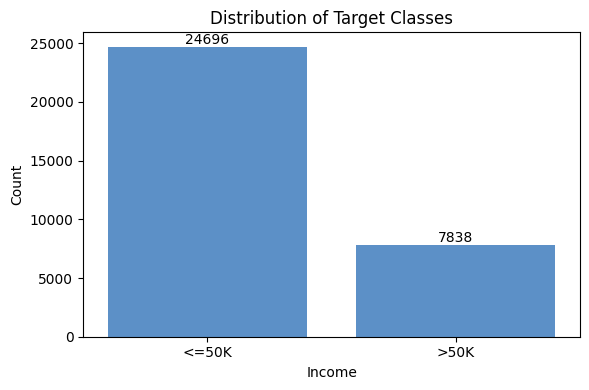

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

target_summary = pd.DataFrame({
    "Count": y.value_counts(),
    "Percentage": (
        y.value_counts(normalize=True)*100
    ).round(2)
})

display(target_summary)

plt.figure(figsize=(6,4))

ax = sns.countplot(
    x=y,
    color="#4a90d9"
)

plt.xticks(
    [0,1],
    ["<=50K",">50K"]
)

plt.title("Distribution of Target Classes")
plt.xlabel("Income")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

#### Interpretation

The target distribution is moderately imbalanced. Approximately 76% of observations belong to the ≤50K class, while only about 24% belong to the >50K class.

This imbalance means that a model could obtain high accuracy simply by predicting the majority class. Therefore, Accuracy alone is insufficient for evaluating model performance. Additional metrics including Precision, Recall, F1-score, and ROC-AUC will also be used.

### 3.2 Train-Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (26027, 12)
Testing set: (6507, 12)


#### Verify Stratification

In [6]:
train_dist = y_train.value_counts(normalize=True)

test_dist = y_test.value_counts(normalize=True)

distribution = pd.DataFrame({
    "Train":train_dist,
    "Test":test_dist
})

display(distribution)

,Train,Test
income_binary,,
0,0.759096,0.759029
1,0.240904,0.240971


#### Interpretation

A stratified train-test split was adopted to preserve the original class proportions in both the training and testing datasets. This approach ensures that both datasets contain approximately the same proportion of high-income and low-income individuals, reducing sampling bias and providing a more reliable estimate of model performance.

## 4. Preprocessing Pipeline

Different preprocessing strategies are applied to numerical and categorical variables. Numerical features are imputed using the median and standardised, while categorical features are imputed using the most frequent category and one-hot encoded.

All preprocessing steps are integrated into a single machine learning pipeline to prevent data leakage during cross-validation and model evaluation.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

numeric_transformer = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num",numeric_transformer,numeric_features),
    ("cat",categorical_transformer,categorical_features)
])

#### Interpretation

The preprocessing workflow applies transformations appropriate to each data type while keeping all operations within a single pipeline. This design ensures that identical preprocessing is consistently applied during cross-validation, hyperparameter tuning, and final model evaluation, thereby preventing information leakage from the test data.

## 5. Cross-Validation Strategy

Stratified K-Fold cross-validation is adopted to maintain the class distribution within each fold. This is particularly important because the target classes are imbalanced.

The same cross-validation strategy will be used consistently throughout model training and hyperparameter optimisation.

In [8]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## Modelling Workflow

The subsequent modelling process follows the same workflow for every classification algorithm:

1. Apply the preprocessing pipeline.
2. Perform Stratified K-Fold cross-validation.
3. Conduct hyperparameter tuning using GridSearchCV.
4. Evaluate the best model on the independent test set.
5. Compare all models using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

This consistent workflow ensures a fair comparison across different machine learning algorithms.

It trains and evaluates four models for the Adult Income binary classification task:

1. Logistic Regression as an interpretable regularized baseline model.
2. Decision Tree as an interpretable non-linear tree-based model.
3. Random Forest as an ensemble tree-based model for variance reduction.
4. XGBoost as a gradient-boosted model for bias reduction and high performance.

## 6. Logistic Regression

Logistic Regression is used as the baseline model because it is simple, interpretable, and appropriate for binary classification. Regularization is controlled through `C`, where smaller values mean stronger regularization. Because the target is imbalanced, `class_weight='balanced'` is included as a candidate setting.

### 6.1 Setup and Compatibility Check

This section assumes Member A has already created `X_train`, `X_test`, `y_train`, `y_test`, `preprocessor`, and `cv`. If those objects are not available, the code attempts to rebuild them from `adult_cleaned (2).xlsx` so this notebook can also run independently.

In [9]:
import os
import warnings

from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
os.makedirs("outputs", exist_ok=True)

In [10]:
required_objects = ["X_train", "X_test", "y_train", "y_test", "preprocessor", "cv"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    print("Missing objects:", missing_objects)
    print("Rebuilding data split and preprocessing pipeline from adult_cleaned (2).xlsx...")

    df = pd.read_excel("adult_cleaned (2).xlsx")
    df["income_binary"] = (
        df["income"].astype(str).str.strip().str.lower().map({"<=50k": 0, ">50k": 1})
    )

    y = df["income_binary"]
    X = df.drop(columns=["income", "income_binary"])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns
    categorical_features = X.select_dtypes(include=["object", "category"]).columns

    try:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", onehot),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
else:
    print("Using existing preprocessing objects.")

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Positive class rate in train:", round(y_train.mean(), 4))
print("Positive class rate in test :", round(y_test.mean(), 4))

Using existing preprocessing objects.
Training set: (26027, 12)
Testing set: (6507, 12)
Positive class rate in train: 0.2409
Positive class rate in test : 0.241


#### Interpretation

This cell checks whether the preprocessing objects created in the previous section are already available. Since the required objects exist, the notebook uses the existing training/test split and preprocessing pipeline. The training set contains 26,027 samples and the test set contains 6,507 samples. The positive class rate is about 24.1% in both sets, confirming that stratified splitting preserved the class distribution.

### 6.2 Shared Evaluation Functions

The Adult Income task is an imbalanced binary classification problem, so the model is evaluated using multiple metrics. Accuracy is reported, but F1-score and ROC-AUC are more important for comparing models because the `>50K` class is the minority class.

In [11]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}


def evaluate_on_test(model_name, fitted_pipeline, X_test, y_test):
    y_pred = fitted_pipeline.predict(X_test)

    if hasattr(fitted_pipeline, "predict_proba"):
        y_score = fitted_pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = fitted_pipeline.decision_function(X_test)

    return pd.DataFrame([
        {
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_score),
            "pr_auc": average_precision_score(y_test, y_score),
        }
    ])


def show_confusion_matrix(model_name, fitted_pipeline, X_test, y_test):
    y_pred = fitted_pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    labels = ["<=50K", ">50K"]

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    print(classification_report(y_test, y_pred, target_names=labels, zero_division=0))

### 6.3 Cross-Validation

This cell builds a Logistic Regression pipeline by combining preprocessing and the classifier. Five-fold stratified cross-validation is used to evaluate the baseline logistic model.

In [12]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])

logistic_cv_scores = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

logistic_cv_summary = pd.DataFrame(logistic_cv_scores).filter(like="test_").agg(["mean", "std"]).T
logistic_cv_summary.index = logistic_cv_summary.index.str.replace("test_", "", regex=False)
display(logistic_cv_summary.round(4))

,mean,std
accuracy,0.8412,0.0031
precision,0.7092,0.0075
recall,0.5775,0.0110
f1,0.6366,0.0084
roc_auc,0.8963,0.0068
pr_auc,0.7282,0.0117


#### Interpretation

These cross-validation results indicate that Logistic Regression serves as a solid baseline. The ROC-AUC of 0.8963 demonstrates a strong capability to distinguish high-income individuals from low-income ones. However, the pre-tuning Recall of 0.5775 suggests that a notable proportion of actual >50K cases are still not captured.

### 6.4 Hyperparameter Tuning

The hyperparameter tuning process used `GridSearchCV` to search over logistic regression hyperparameters, including regularization strength `C`, penalty type, solver, and `class_weight`.

F1-score was selected as the primary tuning metric because the Adult Income dataset is moderately imbalanced: only about 24% of individuals belong to the >50K class. If Accuracy were used for tuning, the model could favor the majority <=50K class and still achieve a high score. F1-score balances Precision and Recall, making it more suitable for selecting models that can identify the minority high-income group. However, the final evaluation still reports multiple metrics, including Accuracy, Precision, Recall, ROC-AUC, and PR-AUC, so the model is not judged by F1-score alone.

In [13]:
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced"],
}

logistic_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

logistic_search.fit(X_train, y_train)

print("Best Logistic Regression parameters:")
print(logistic_search.best_params_)
print(f"Best CV F1-score: {logistic_search.best_score_:.4f}")

logistic_best = logistic_search.best_estimator_

Best Logistic Regression parameters:
{'model__C': 1, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV F1-score: 0.6696


### 6.5 Test Evaluation

The confusion matrix is shown as a heatmap to support this interpretation. This format was selected because the color gradient helps stakeholders quickly locate where the model makes the most errors, especially false negatives and false positives. It shows how many individuals were correctly classified as `<=50K` or `>50K`, and how many were misclassified.

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.8031,0.5603,0.8501,0.6754,0.9008,0.7453


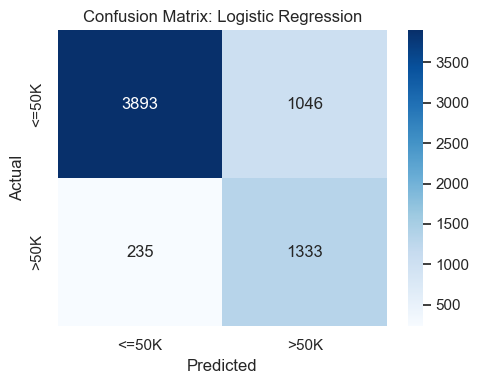

              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      4939
        >50K       0.56      0.85      0.68      1568

    accuracy                           0.80      6507
   macro avg       0.75      0.82      0.77      6507
weighted avg       0.85      0.80      0.81      6507



In [14]:
logistic_test_results = evaluate_on_test("Logistic Regression", logistic_best, X_test, y_test)
display(logistic_test_results.round(4))

show_confusion_matrix("Logistic Regression", logistic_best, X_test, y_test)

#### Interpretation

The tuned Logistic Regression model was evaluated on the independent test set, achieving Accuracy = 0.8031, Precision = 0.5603, Recall = 0.8501, F1-score = 0.6754, ROC-AUC = 0.9008, and PR-AUC = 0.7453. The high Recall indicates that the model is effective at identifying many individuals earning >50K, although Precision is moderate.

## 7. Decision Tree

Decision Tree is used as an interpretable non-linear model. It can capture feature interactions and threshold effects, but an unconstrained tree can easily overfit. Therefore, key regularization-style hyperparameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf` are tuned using stratified cross-validation.

### 7.1 Cross-Validation

In [15]:
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

tree_cv_scores = cross_validate(
    tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

tree_cv_summary = pd.DataFrame(tree_cv_scores).filter(like="test_").agg(["mean", "std"]).T
tree_cv_summary.index = tree_cv_summary.index.str.replace("test_", "", regex=False)
display(tree_cv_summary.round(4))

,mean,std
accuracy,0.7893,0.0031
precision,0.5643,0.0066
recall,0.5491,0.0160
f1,0.5565,0.0097
roc_auc,0.7232,0.0044
pr_auc,0.4355,0.0050


#### Interpretation

Before tuning, the Decision Tree model was evaluated using five-fold stratified cross-validation, achieving a mean CV accuracy of 0.7893, F1-score of 0.5565, ROC-AUC of 0.7232, and PR-AUC of 0.4355. These results suggest that the default Decision Tree is less stable and less accurate than Logistic Regression, likely because an unconstrained tree tends to overfit.

### 7.2 Hyperparameter Tuning

`GridSearchCV` was used to tune the Decision Tree hyperparameters, including splitting criterion, maximum depth, minimum samples per split, minimum samples per leaf, and `class_weight`. The final selected best model used `class_weight='balanced'`, entropy as the splitting criterion, no fixed maximum depth, `min_samples_leaf=20`, and `min_samples_split=2`.

In [16]:
tree_param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [1, 5, 20],
    "model__class_weight": [None, "balanced"],
}

tree_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

tree_search.fit(X_train, y_train)

print("Best Decision Tree parameters:")
print(tree_search.best_params_)
print(f"Best CV F1-score: {tree_search.best_score_:.4f}")

tree_best = tree_search.best_estimator_

Best Decision Tree parameters:
{'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 20, 'model__min_samples_split': 2}
Best CV F1-score: 0.6463


### 7.3 Test Evaluation

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Decision Tree,0.783,0.5318,0.831,0.6486,0.8797,0.705


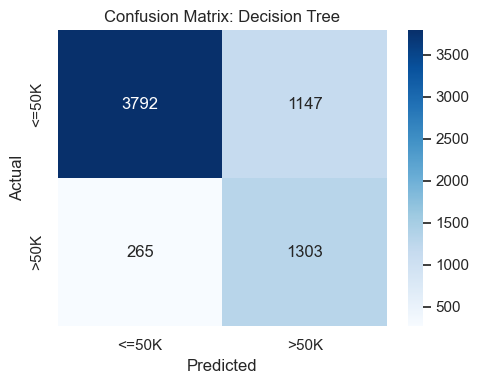

              precision    recall  f1-score   support

       <=50K       0.93      0.77      0.84      4939
        >50K       0.53      0.83      0.65      1568

    accuracy                           0.78      6507
   macro avg       0.73      0.80      0.75      6507
weighted avg       0.84      0.78      0.80      6507



In [17]:
tree_test_results = evaluate_on_test("Decision Tree", tree_best, X_test, y_test)
display(tree_test_results.round(4))

show_confusion_matrix("Decision Tree", tree_best, X_test, y_test)

#### Interpretation

The tuned Decision Tree model was evaluated on the independent test set. Compared with Logistic Regression, the Decision Tree has slightly lower overall performance. This may be because a single decision tree is more sensitive to local patterns and can overfit the training data, especially with many one-hot encoded categorical features. In contrast, Logistic Regression with L2 regularization provides a more stable baseline and generalizes better on this dataset.

### 7.4 Optional: Simple Decision Tree Visualisation

The tuned tree may be too large to visualize clearly. For stakeholder explanation, a shallow tree can be trained only for illustration. This is not necessarily the best-performing model; it is a simplified explanation tool. It helps stakeholders understand how tree-based models make decisions using features such as education, occupation, age, and working hours.

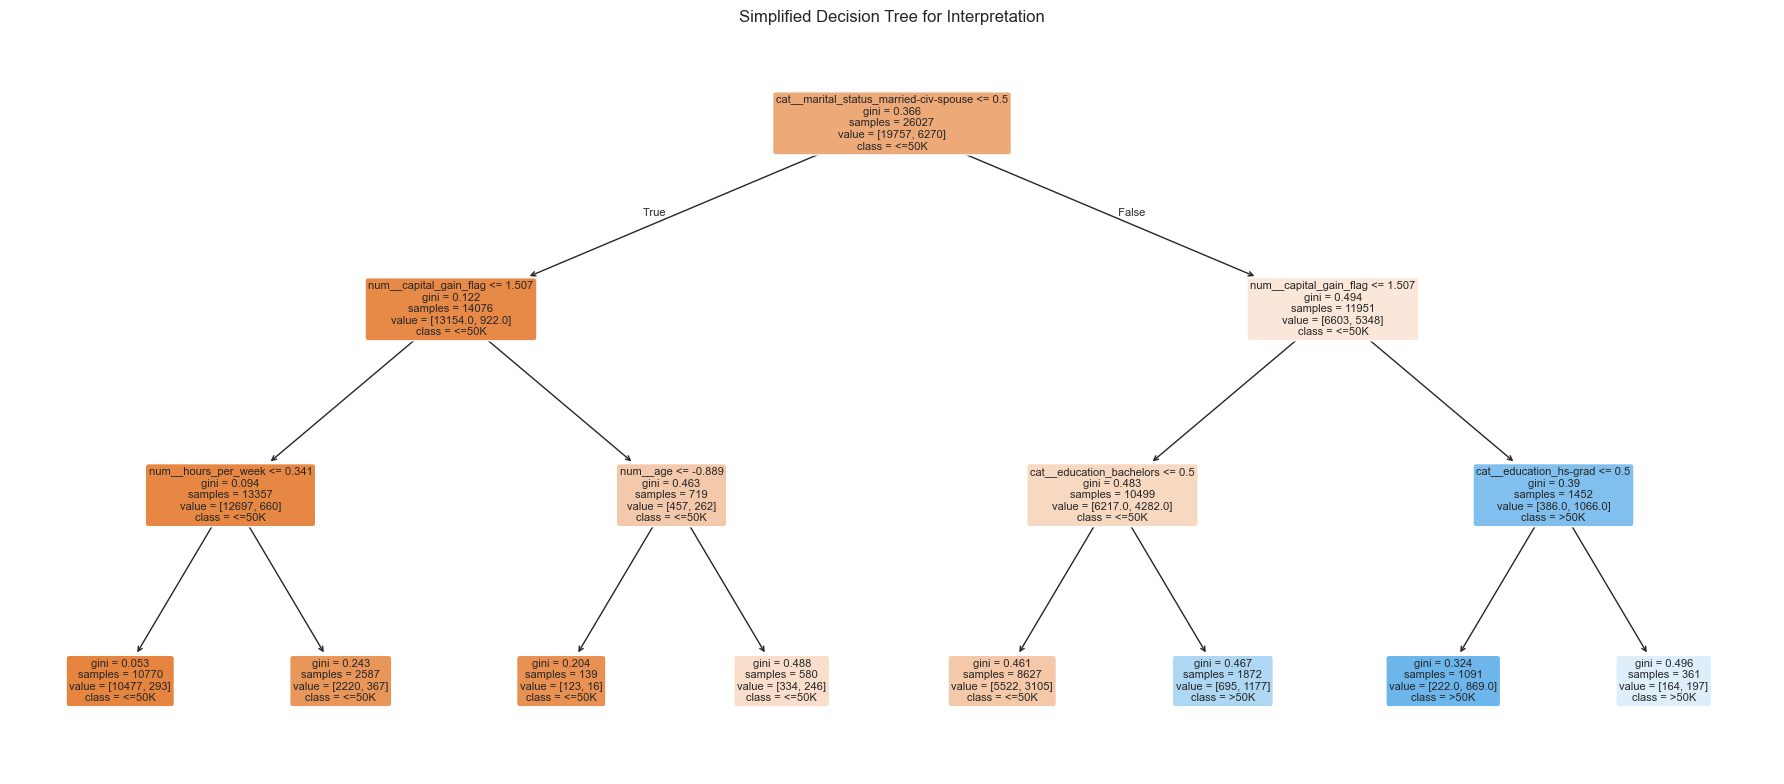

Saved: outputs/shallow_tree.png


In [18]:
shallow_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=RANDOM_STATE)),
])

shallow_tree_pipeline.fit(X_train, y_train)

try:
    feature_names = shallow_tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
except Exception:
    feature_names = None

plt.figure(figsize=(18, 8))
plot_tree(
    shallow_tree_pipeline.named_steps["model"],
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Simplified Decision Tree for Interpretation")
plt.tight_layout()
plt.savefig("outputs/shallow_tree.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: outputs/shallow_tree.png")

## 8. Random Forest

Random Forest is an ensemble tree model based on bagging. It trains many decision trees on bootstrap samples and averages their predictions, which usually reduces variance compared with a single Decision Tree. For this income classification task, Random Forest is useful because it can capture non-linear relationships and interactions among demographic and work-related variables without requiring strong linear assumptions.

### 8.1 Cross-Validation

The first step is to evaluate a baseline Random Forest using the same five-fold stratified cross-validation strategy and the same metric set used for the previous models. This keeps the model comparison consistent.

In [19]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_cv_scores = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

rf_cv_summary = pd.DataFrame(rf_cv_scores).filter(like="test_").agg(["mean", "std"]).T
rf_cv_summary.index = rf_cv_summary.index.str.replace("test_", "", regex=False)
display(rf_cv_summary.round(4))

,mean,std
accuracy,0.8233,0.0041
precision,0.6527,0.0116
recall,0.5700,0.0159
f1,0.6084,0.0104
roc_auc,0.8721,0.0067
pr_auc,0.6701,0.0076


### 8.2 Hyperparameter Tuning

For Random Forest, the most important hyperparameters are the number of trees, tree depth, number of features considered at each split, and minimum samples per leaf. A randomized search is used here to keep the tuning process efficient while still exploring the main bias-variance controls. The model is refit using the configuration with the best cross-validated F1-score.

In [20]:
rf_param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [8, 12, 20, None],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [1, 3, 5],
    "model__max_features": ["sqrt", 0.5],
    "model__class_weight": [None, "balanced"],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=18,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=True,
)

rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_search.best_params_)
print(f"Best CV F1-score: {rf_search.best_score_:.4f}")

rf_tuning_results = pd.DataFrame(rf_search.cv_results_)
rf_tuning_results = rf_tuning_results.sort_values("rank_test_score")[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "params",
]].head(5)

display(rf_tuning_results)

rf_best = rf_search.best_estimator_

Best Random Forest parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__class_weight': 'balanced'}
Best CV F1-score: 0.6748


,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
2,1,0.674763,0.010171,0.826611,"{'model__n_estimators': 300, 'model__min_sampl..."
13,2,0.671812,0.008838,0.802578,"{'model__n_estimators': 200, 'model__min_sampl..."
10,3,0.669440,0.008116,0.707509,"{'model__n_estimators': 200, 'model__min_sampl..."
15,4,0.669384,0.008527,0.801471,"{'model__n_estimators': 200, 'model__min_sampl..."
17,5,0.668156,0.009119,0.706765,"{'model__n_estimators': 500, 'model__min_sampl..."


### 8.3 Test Evaluation

After tuning, the selected Random Forest is evaluated on the hold-out test set. The test set is not used during cross-validation or hyperparameter tuning, so these scores provide a more realistic estimate of final model performance.

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.8362,0.6329,0.7621,0.6916,0.8982,0.7359


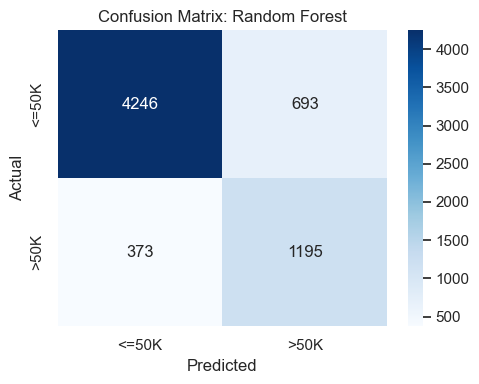

              precision    recall  f1-score   support

       <=50K       0.92      0.86      0.89      4939
        >50K       0.63      0.76      0.69      1568

    accuracy                           0.84      6507
   macro avg       0.78      0.81      0.79      6507
weighted avg       0.85      0.84      0.84      6507



In [21]:
rf_test_results = evaluate_on_test("Random Forest", rf_best, X_test, y_test)
display(rf_test_results.round(4))

show_confusion_matrix("Random Forest", rf_best, X_test, y_test)

## 9. XGBoost

XGBoost is a gradient-boosted tree model. Unlike Random Forest, which builds many trees independently, boosting builds trees sequentially so that each new tree focuses on the errors made by the current ensemble. This often gives strong predictive performance on tabular data, but it also makes hyperparameter tuning more important.

The code below tries to use `xgboost.XGBClassifier` if the package is available. If `xgboost` is not installed in the environment, the notebook uses `HistGradientBoostingClassifier` from scikit-learn as a runnable gradient-boosted tree fallback.

In [22]:
# Build a dense preprocessor for gradient boosting fallback models that do not accept sparse matrices.
try:
    dense_onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    dense_onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

dense_categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", dense_onehot),
])

dense_preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", dense_categorical_transformer, categorical_features),
])

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

if XGBOOST_AVAILABLE:
    xgb_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    xgb_preprocessor = preprocessor
    xgb_model_name = "XGBoost"
else:
    print("xgboost is not installed. Using HistGradientBoostingClassifier as a gradient-boosted tree fallback.")
    xgb_model = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
    xgb_preprocessor = dense_preprocessor
    xgb_model_name = "XGBoost-style Gradient Boosting"

xgb_pipeline = Pipeline([
    ("preprocessor", xgb_preprocessor),
    ("model", xgb_model),
])

### 9.1 Cross-Validation

The baseline boosting model is evaluated with the same stratified cross-validation setup. This makes it possible to compare boosting directly with Logistic Regression, Decision Tree, and Random Forest.

In [23]:
xgb_cv_scores = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

xgb_cv_summary = pd.DataFrame(xgb_cv_scores).filter(like="test_").agg(["mean", "std"]).T
xgb_cv_summary.index = xgb_cv_summary.index.str.replace("test_", "", regex=False)
display(xgb_cv_summary.round(4))

,mean,std
accuracy,0.8447,0.0036
precision,0.7053,0.0124
recall,0.6108,0.0134
f1,0.6546,0.0080
roc_auc,0.8990,0.0049
pr_auc,0.7350,0.0076


### 9.2 Hyperparameter Tuning

For boosting models, the main tuning trade-off is between learning rate, number of boosting rounds, and tree complexity. Smaller learning rates usually require more trees but can improve generalization. The search space below focuses on these high-impact parameters.

In [24]:
if XGBOOST_AVAILABLE:
    xgb_param_distributions = {
        "model__n_estimators": [150, 250, 400, 600],
        "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "model__max_depth": [3, 4, 5, 6],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
        "model__min_child_weight": [1, 5, 10],
        "model__reg_lambda": [1, 5, 10],
    }
else:
    xgb_param_distributions = {
        "model__max_iter": [150, 250, 400, 600],
        "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__min_samples_leaf": [10, 20, 50],
        "model__l2_regularization": [0.0, 0.1, 1.0],
    }

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_distributions,
    n_iter=18,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=True,
)

xgb_search.fit(X_train, y_train)

print(f"Best {xgb_model_name} parameters:")
print(xgb_search.best_params_)
print(f"Best CV F1-score: {xgb_search.best_score_:.4f}")

xgb_tuning_results = pd.DataFrame(xgb_search.cv_results_)
xgb_tuning_results = xgb_tuning_results.sort_values("rank_test_score")[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "params",
]].head(5)

display(xgb_tuning_results)

xgb_best = xgb_search.best_estimator_

Best XGBoost parameters:
{'model__subsample': 1.0, 'model__reg_lambda': 5, 'model__n_estimators': 250, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.2, 'model__colsample_bytree': 1.0}
Best CV F1-score: 0.6614


,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
5,1,0.661438,0.008746,0.719164,"{'model__subsample': 1.0, 'model__reg_lambda':..."
8,2,0.661420,0.011836,0.681272,"{'model__subsample': 0.8, 'model__reg_lambda':..."
10,3,0.660876,0.009352,0.722981,"{'model__subsample': 1.0, 'model__reg_lambda':..."
3,4,0.660228,0.010263,0.760611,"{'model__subsample': 1.0, 'model__reg_lambda':..."
9,5,0.659134,0.010565,0.682894,"{'model__subsample': 0.8, 'model__reg_lambda':..."


### 9.3 Test Evaluation

The tuned boosting model is evaluated on the independent test set. Because the positive income class is the minority class, F1-score and PR-AUC are especially important in addition to accuracy and ROC-AUC.

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost,0.8514,0.7151,0.6371,0.6739,0.9066,0.7581


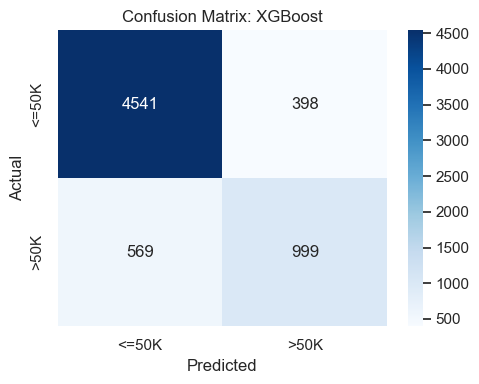

              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      4939
        >50K       0.72      0.64      0.67      1568

    accuracy                           0.85      6507
   macro avg       0.80      0.78      0.79      6507
weighted avg       0.85      0.85      0.85      6507



In [25]:
xgb_test_results = evaluate_on_test(xgb_model_name, xgb_best, X_test, y_test)
display(xgb_test_results.round(4))

show_confusion_matrix(xgb_model_name, xgb_best, X_test, y_test)

## 10. Model Performance Comparison

This section combines all tuned models into one comparison table and visualizes the main evaluation metrics. The comparison uses test-set results because the final model should be selected based on performance on data not used for training or tuning.

### 10.1 Comparison Table

In [26]:
result_frames = []
for result_name in [
    "logistic_test_results",
    "tree_test_results",
    "rf_test_results",
    "xgb_test_results",
]:
    if result_name in globals():
        result_frames.append(globals()[result_name])

comparison_table = pd.concat(result_frames, ignore_index=True)
comparison_table = comparison_table.sort_values("f1", ascending=False).reset_index(drop=True)

display(comparison_table.round(4))

comparison_table.to_csv("outputs/model_performance_comparison.csv", index=False)
print("Saved: outputs/model_performance_comparison.csv")

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.8362,0.6329,0.7621,0.6916,0.8982,0.7359
1,Logistic Regression,0.8031,0.5603,0.8501,0.6754,0.9008,0.7453
2,XGBoost,0.8514,0.7151,0.6371,0.6739,0.9066,0.7581
3,Decision Tree,0.7830,0.5318,0.8310,0.6486,0.8797,0.7050


Saved: outputs/model_performance_comparison.csv


### 10.2 Metric Bar Charts

The bar charts compare the models across accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC. F1-score is useful for balancing precision and recall, while PR-AUC is helpful when the positive class is less frequent.

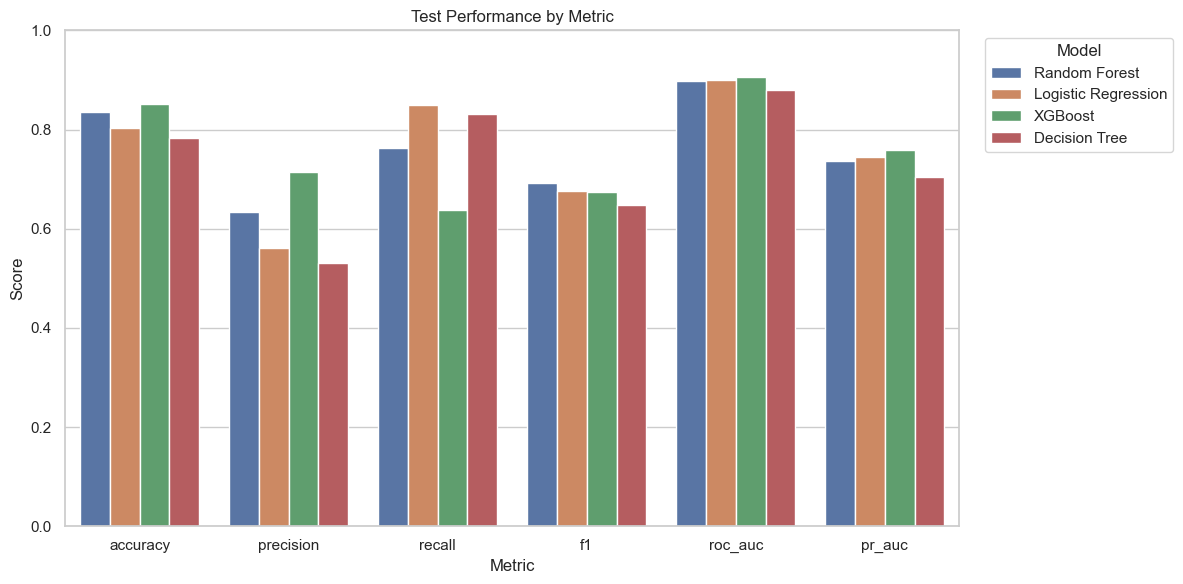

Saved: outputs/model_metric_bar_charts.png


In [27]:
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
plot_df = comparison_table.melt(
    id_vars="model",
    value_vars=metric_cols,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.title("Test Performance by Metric")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("outputs/model_metric_bar_charts.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: outputs/model_metric_bar_charts.png")

### 10.3 ROC Curves

ROC curves show the trade-off between true positive rate and false positive rate across classification thresholds. A higher curve and larger ROC-AUC indicate better ranking ability.

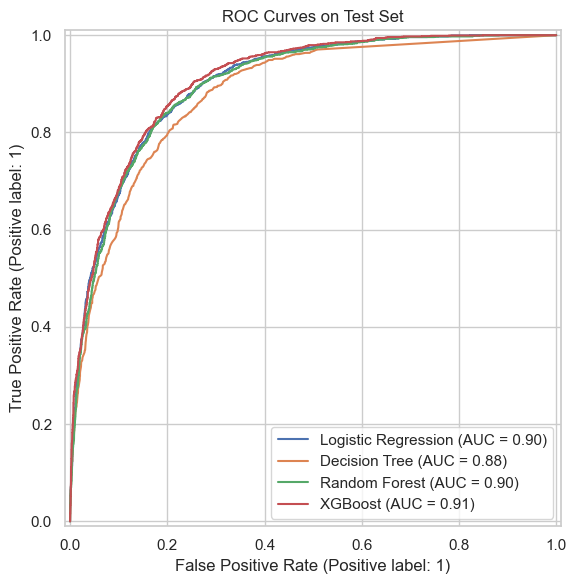

Saved: outputs/roc_curves.png


In [28]:
best_models = {}
if "logistic_best" in globals():
    best_models["Logistic Regression"] = logistic_best
if "tree_best" in globals():
    best_models["Decision Tree"] = tree_best
if "rf_best" in globals():
    best_models["Random Forest"] = rf_best
if "xgb_best" in globals():
    best_models[xgb_model_name] = xgb_best

plt.figure(figsize=(8, 6))
ax = plt.gca()
for model_name, fitted_model in best_models.items():
    RocCurveDisplay.from_estimator(fitted_model, X_test, y_test, ax=ax, name=model_name)

plt.title("ROC Curves on Test Set")
plt.tight_layout()
plt.savefig("outputs/roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: outputs/roc_curves.png")

### 10.4 Precision-Recall Curves

Precision-recall curves focus on performance for the positive class (`>50K`). This is important because the dataset is imbalanced and the positive class is less common than the negative class.

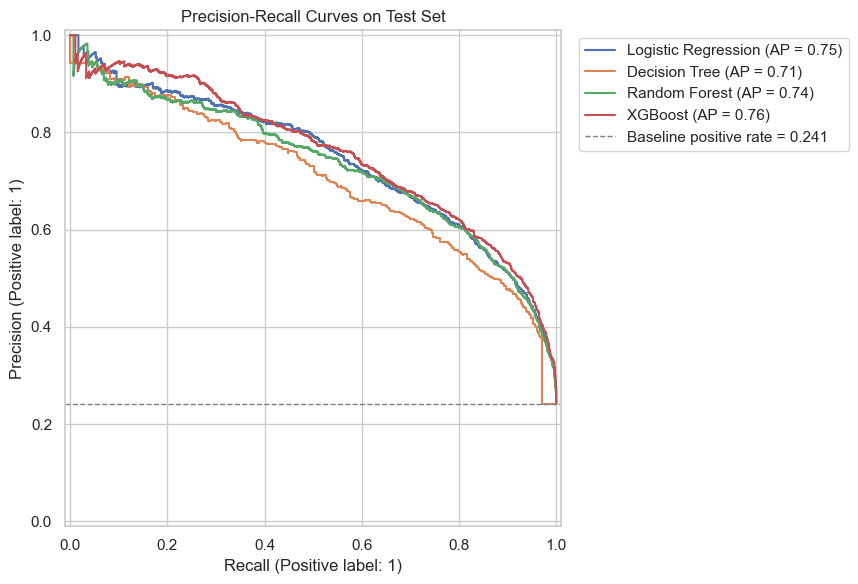

Saved: outputs/precision_recall_curves.png


In [29]:
plt.figure(figsize=(8, 6))
ax = plt.gca()
for model_name, fitted_model in best_models.items():
    PrecisionRecallDisplay.from_estimator(fitted_model, X_test, y_test, ax=ax, name=model_name)

positive_rate = y_test.mean()
plt.axhline(positive_rate, color="gray", linestyle="--", linewidth=1, label=f"Baseline positive rate = {positive_rate:.3f}")
plt.title("Precision-Recall Curves on Test Set")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("outputs/precision_recall_curves.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: outputs/precision_recall_curves.png")

## 11. Best Model Selection

The best model is selected using F1-score as the primary metric because the target variable is imbalanced and we care about both correctly identifying higher-income individuals and avoiding too many false positives. ROC-AUC and PR-AUC are used as supporting metrics because they evaluate the quality of predicted probabilities across different thresholds.

In [30]:
primary_metric = "f1"

best_row = comparison_table.sort_values(
    [primary_metric, "pr_auc", "roc_auc"],
    ascending=False,
).iloc[0]

print(f"Best model based on test {primary_metric.upper()}: {best_row['model']}")
print(f"Test F1-score : {best_row['f1']:.4f}")
print(f"Test ROC-AUC  : {best_row['roc_auc']:.4f}")
print(f"Test PR-AUC   : {best_row['pr_auc']:.4f}")
print(f"Test accuracy : {best_row['accuracy']:.4f}")

best_model_summary = pd.DataFrame([best_row])
display(best_model_summary.round(4))

Best model based on test F1: Random Forest
Test F1-score : 0.6916
Test ROC-AUC  : 0.8982
Test PR-AUC   : 0.7359
Test accuracy : 0.8362


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.8362,0.6329,0.7621,0.6916,0.8982,0.7359


#### Final Interpretation

Based on the test-set comparison, Random Forest is selected as the best final model because it achieves the highest test F1-score. This means it provides the best balance between precision and recall under our chosen primary metric. However, XGBoost achieves the highest ROC-AUC and PR-AUC, suggesting that it has slightly stronger probability ranking ability. Therefore, if the goal were probability-based ranking or threshold adjustment, XGBoost would also be a strong candidate. For this project, since F1-score is prioritized due to class imbalance, Random Forest is selected as the final model.

## 12. Feature Importance

This section explains which variables contribute most to the selected final model. Because the final estimator is inside a preprocessing pipeline, feature importance is calculated in two complementary ways:

1. Model-based importance, when the estimator provides `feature_importances_` or `coef_`.
2. Permutation importance on the test set, which measures how much F1-score drops when each original feature is shuffled.

Permutation importance is emphasized because it is model-agnostic, uses held-out data, and is aligned with the project primary metric: F1-score for the minority `>50K` class.


In [31]:
from sklearn.inspection import permutation_importance

# Select the fitted final model chosen in Section 11.
best_model_name = str(best_row["model"])
best_final_model = best_models.get(best_model_name)

# Fallback for cases where the display name differs slightly, such as the XGBoost fallback model.
if best_final_model is None:
    for candidate_name, candidate_model in best_models.items():
        if candidate_name == best_model_name or candidate_name in best_model_name or best_model_name in candidate_name:
            best_final_model = candidate_model
            best_model_name = candidate_name
            break

if best_final_model is None:
    raise ValueError("The selected best model was not found in best_models.")

print(f"Selected final model for interpretation: {best_model_name}")
print(best_final_model)


Selected final model for interpretation: Random Forest
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'hours_per_week', 'capital_gain_flag', 'capital_loss_flag'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                             

In [34]:
def get_pipeline_feature_names(fitted_pipeline):
    preprocessor_step = fitted_pipeline.named_steps["preprocessor"]
    try:
        return preprocessor_step.get_feature_names_out()
    except Exception:
        return np.array([f"feature_{i}" for i in range(preprocessor_step.transform(X_train.iloc[:1]).shape[1])])


def original_feature_from_transformed_name(feature_name):
    cleaned = str(feature_name).replace("num__", "").replace("cat__", "")

    for col in list(numeric_features):
        if cleaned == col:
            return col

    # Sort by length so longer names are matched before shorter prefixes.
    for col in sorted(list(categorical_features), key=len, reverse=True):
        if cleaned == col or cleaned.startswith(f"{col}_"):
            return col

    return cleaned


transformed_feature_names = get_pipeline_feature_names(best_final_model)
final_estimator = best_final_model.named_steps["model"]

model_importance = None
if hasattr(final_estimator, "feature_importances_"):
    model_importance = pd.DataFrame({
        "transformed_feature": transformed_feature_names,
        "importance": final_estimator.feature_importances_,
    })
elif hasattr(final_estimator, "coef_"):
    model_importance = pd.DataFrame({
        "transformed_feature": transformed_feature_names,
        "importance": np.abs(final_estimator.coef_).ravel(),
    })

if model_importance is not None:
    model_importance["original_feature"] = model_importance["transformed_feature"].map(original_feature_from_transformed_name)
    model_importance_grouped = (
        model_importance
        .groupby("original_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    model_importance_grouped["importance_pct"] = model_importance_grouped["importance"] / model_importance_grouped["importance"].sum()
    display(model_importance_grouped.head(15).round(4))
else:
    print("The selected estimator does not expose feature_importances_ or coef_. Use permutation importance below.")


,original_feature,importance,importance_pct
0,marital_status,0.1898,0.1898
1,age,0.1609,0.1609
2,relationship,0.1567,0.1567
3,education,0.1219,0.1219
4,occupation,0.1036,0.1036
5,hours_per_week,0.0881,0.0881
6,capital_gain_flag,0.0436,0.0436
7,workclass,0.0403,0.0403
8,sex,0.0387,0.0387
9,native_country,0.0250,0.0250


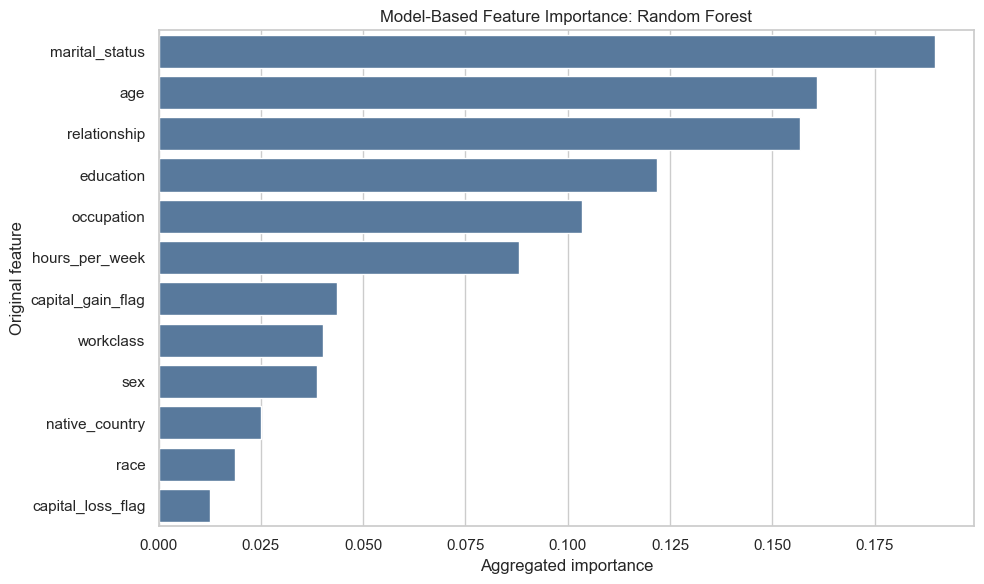

Saved: outputs/feature_importance_model_based.png


In [36]:
if model_importance is not None:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=model_importance_grouped.head(15),
        x="importance",
        y="original_feature",
        color="#4C78A8",
    )
    plt.title(f"Model-Based Feature Importance: {best_model_name}")
    plt.xlabel("Aggregated importance")
    plt.ylabel("Original feature")
    plt.tight_layout()
    plt.savefig("outputs/feature_importance_model_based.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved: outputs/feature_importance_model_based.png")

,feature,importance_mean,importance_std
0,education,0.0670,0.0067
1,age,0.0660,0.0057
2,marital_status,0.0604,0.0067
3,relationship,0.0562,0.0042
4,occupation,0.0428,0.0058
5,hours_per_week,0.0260,0.0028
6,capital_gain_flag,0.0230,0.0021
7,workclass,0.0070,0.0041
8,capital_loss_flag,0.0064,0.0011
9,sex,0.0051,0.0036


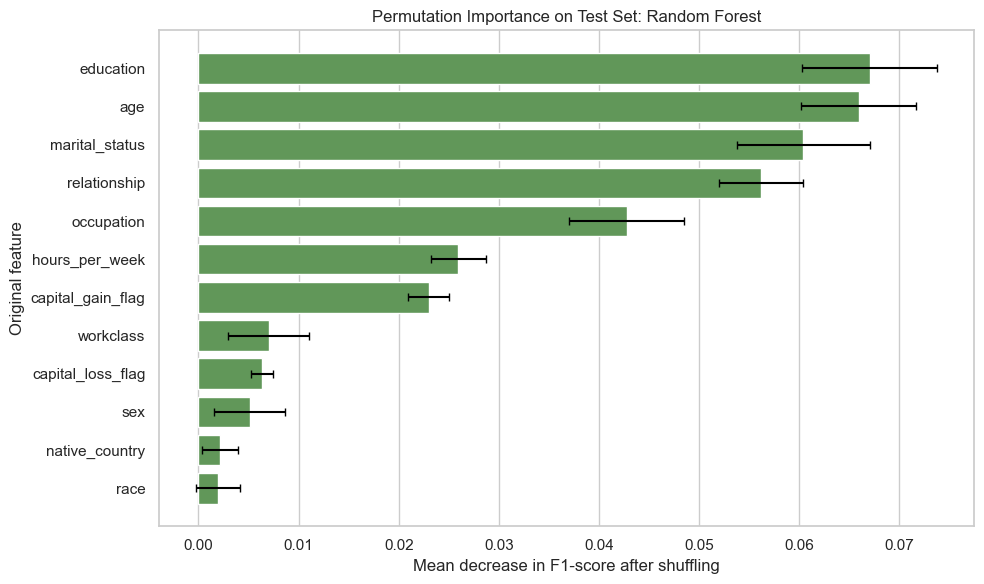

Saved: outputs/feature_importance_permutation.png
Saved: outputs/permutation_importance.csv


In [37]:
permutation_result = permutation_importance(
    best_final_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1",
    n_jobs=-1,
)

permutation_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

display(permutation_importance_df.head(15).round(4))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=permutation_importance_df.head(15),
    x="importance_mean",
    y="feature",
    color="#59A14F",
)
plt.errorbar(
    x=permutation_importance_df.head(15)["importance_mean"],
    y=np.arange(min(15, len(permutation_importance_df))),
    xerr=permutation_importance_df.head(15)["importance_std"],
    fmt="none",
    ecolor="black",
    capsize=3,
)
plt.title(f"Permutation Importance on Test Set: {best_model_name}")
plt.xlabel("Mean decrease in F1-score after shuffling")
plt.ylabel("Original feature")
plt.tight_layout()
plt.savefig("outputs/feature_importance_permutation.png", dpi=300, bbox_inches="tight")
plt.show()

permutation_importance_df.to_csv("outputs/permutation_importance.csv", index=False)
print("Saved: outputs/feature_importance_permutation.png")
print("Saved: outputs/permutation_importance.csv")


#### Interpretation

The feature importance analysis shows which variables the selected **Random Forest** model relies on most when predicting whether an individual earns more than **`>50K`**. According to the permutation importance results, **education**, **age**, **marital status**, **relationship**, and **occupation** are the most influential predictors. These variables are closely associated with an individual's human capital, employment characteristics, and household circumstances, all of which are well-established factors affecting income. In comparison, variables such as **race** and **native country** contribute relatively little to the model's predictive performance.

Model-based feature importance provides a useful summary of how the Random Forest model uses different variables during training, but it may overestimate the importance of variables with many categories or those represented by multiple one-hot encoded features. For this reason, **permutation importance** is regarded as the primary interpretation method in this study. By evaluating the decrease in the **F1-score** on the independent test set after randomly shuffling each feature, it offers a more reliable estimate of each original variable's contribution to the model's predictive performance.

## 13. SHAP Explanations

SHAP values are used to explain both global model behaviour and individual predictions. Unlike a single feature-importance ranking, SHAP shows whether a feature pushes a prediction toward `>50K` or toward `<=50K`.

For this project, SHAP is applied to a sample of the transformed test set to keep the notebook efficient. If the `shap` package is not available in the environment, the cell will skip the plots instead of breaking the rest of the notebook.


In [55]:
def to_dense_array(matrix):
    if hasattr(matrix, "toarray"):
        return matrix.toarray()
    return np.asarray(matrix)


try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("shap is not installed. Install shap to run Section 13 explanations.")

if SHAP_AVAILABLE:
    interpretation_sample_size = min(200, len(X_test))
    X_shap_raw = X_test.sample(n=interpretation_sample_size, random_state=RANDOM_STATE)

    shap_preprocessor = best_final_model.named_steps["preprocessor"]
    shap_estimator = best_final_model.named_steps["model"]
    shap_feature_names = get_pipeline_feature_names(best_final_model)

    X_shap_transformed = to_dense_array(shap_preprocessor.transform(X_shap_raw))
    X_shap_transformed_df = pd.DataFrame(X_shap_transformed, columns=shap_feature_names, index=X_shap_raw.index)

    try:
        shap_explainer = shap.TreeExplainer(shap_estimator)
        shap_values_raw = shap_explainer.shap_values(X_shap_transformed_df)
        shap_expected_value = shap_explainer.expected_value

        if isinstance(shap_values_raw, list):
            shap_values = shap_values_raw[1]
            if isinstance(shap_expected_value, (list, np.ndarray)):
                shap_base_value = shap_expected_value[1]
            else:
                shap_base_value = shap_expected_value
        elif np.ndim(shap_values_raw) == 3:
            shap_values = shap_values_raw[:, :, 1]
            shap_base_value = shap_expected_value[1] if isinstance(shap_expected_value, (list, np.ndarray)) else shap_expected_value
        else:
            shap_values = shap_values_raw
            shap_base_value = shap_expected_value

        print("SHAP values shape:", np.shape(shap_values))
        print("Base value:", shap_base_value)
    except Exception as error:
        SHAP_AVAILABLE = False
        print("SHAP could not be calculated for the selected estimator:")
        print(error)


SHAP values shape: (200, 103)
Base value: 0.4999675192112516


In [56]:
if SHAP_AVAILABLE:
    sample_idx = 0

    reconstructed_prediction = (
        shap_base_value +
        shap_values[sample_idx].sum()
    )
    
    model_prediction = best_final_model.predict_proba(
        X_shap_raw.iloc[[sample_idx]]
    )[0,1]
    
    print(f"Model prediction: {model_prediction:.6f}")
    print(f"Base value + ΣSHAP: {reconstructed_prediction:.6f}")
    print(f"Difference: {abs(model_prediction-reconstructed_prediction):.8f}")

Model prediction: 0.864174
Base value + ΣSHAP: 0.864174
Difference: 0.00000009


> #### SHAP Additivity Check
>
> One of the most important properties of SHAP values is **local accuracy (additivity)**. For an individual prediction, the model output should equal the base value plus the sum of all SHAP contributions.
>
> This check verifies that the SHAP explanation faithfully reconstructs the model prediction.

,original_feature,mean_abs_shap
0,marital_status,0.1162
1,education,0.1148
2,relationship,0.0989
3,occupation,0.0925
4,age,0.0668
5,hours_per_week,0.0488
6,capital_gain_flag,0.0434
7,sex,0.0293
8,workclass,0.0210
9,capital_loss_flag,0.0131


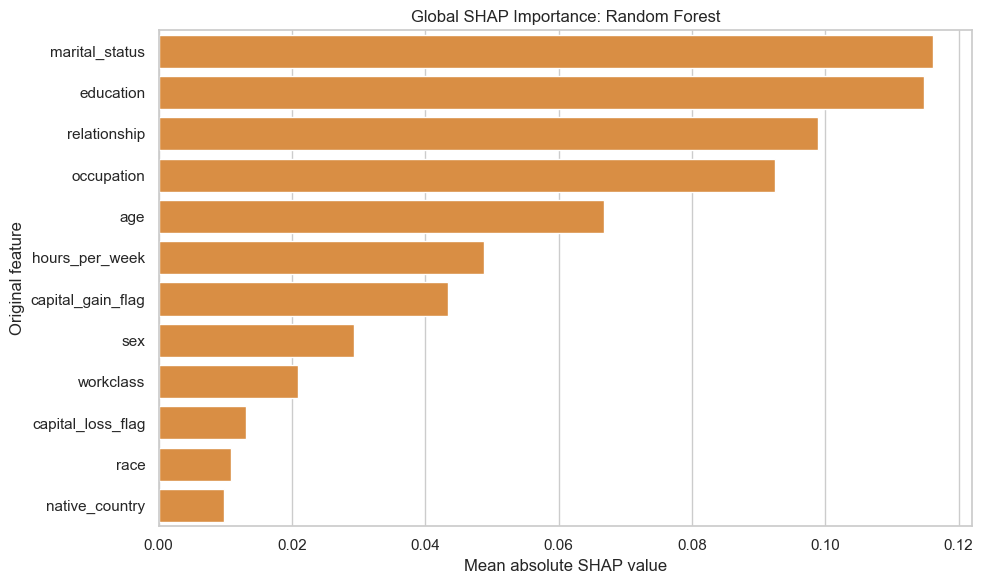

Saved: outputs/shap_global_importance.csv
Saved: outputs/shap_global_importance.png


In [57]:
if SHAP_AVAILABLE:
    shap_importance_transformed = pd.DataFrame({
        "transformed_feature": shap_feature_names,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    })
    shap_importance_transformed["original_feature"] = shap_importance_transformed["transformed_feature"].map(original_feature_from_transformed_name)

    shap_importance_grouped = (
        shap_importance_transformed
        .groupby("original_feature", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    display(shap_importance_grouped.head(15).round(4))
    shap_importance_grouped.to_csv("outputs/shap_global_importance.csv", index=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=shap_importance_grouped.head(15),
        x="mean_abs_shap",
        y="original_feature",
        color="#F28E2B",
    )
    plt.title(f"Global SHAP Importance: {best_model_name}")
    plt.xlabel("Mean absolute SHAP value")
    plt.ylabel("Original feature")
    plt.tight_layout()
    plt.savefig("outputs/shap_global_importance.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved: outputs/shap_global_importance.csv")
    print("Saved: outputs/shap_global_importance.png")


In [58]:
if SHAP_AVAILABLE and model_importance is not None:
    comparison_df = (
        model_importance_grouped[["original_feature", "importance"]]
        .rename(columns={"importance": "model_importance"})
        .merge(
            permutation_importance_df[["feature", "importance_mean"]].rename(
                columns={
                    "feature": "original_feature",
                    "importance_mean": "permutation_importance",
                }
            ),
            on="original_feature",
            how="outer",
        )
        .merge(
            shap_importance_grouped,
            on="original_feature",
            how="outer",
        )
    )

    comparison_df = comparison_df.fillna(0)
    display(comparison_df.sort_values("mean_abs_shap", ascending=False).round(4))

    comparison_df.to_csv("outputs/importance_comparison.csv", index=False)
    print("Saved: outputs/importance_comparison.csv")

,original_feature,model_importance,permutation_importance,mean_abs_shap
5,marital_status,0.1898,0.0604,0.1162
3,education,0.1219,0.0670,0.1148
9,relationship,0.1567,0.0562,0.0989
7,occupation,0.1036,0.0428,0.0925
0,age,0.1609,0.0660,0.0668
4,hours_per_week,0.0881,0.0260,0.0488
1,capital_gain_flag,0.0436,0.0230,0.0434
10,sex,0.0387,0.0051,0.0293
11,workclass,0.0403,0.0070,0.0210
2,capital_loss_flag,0.0127,0.0064,0.0131


Saved: outputs/importance_comparison.csv


> #### Comparing Model-Based, Permutation, and SHAP Importance
>
> The three importance methods measure different concepts:
>
> - Model-based importance measures how much each feature contributes to impurity reduction during training.
> - Permutation importance measures the decrease in F1-score after shuffling a feature on the test set.
> - SHAP importance measures the average magnitude of feature contributions across individual predictions.
>
> Comparing the rankings helps identify features that are consistently important across multiple explanation methods.

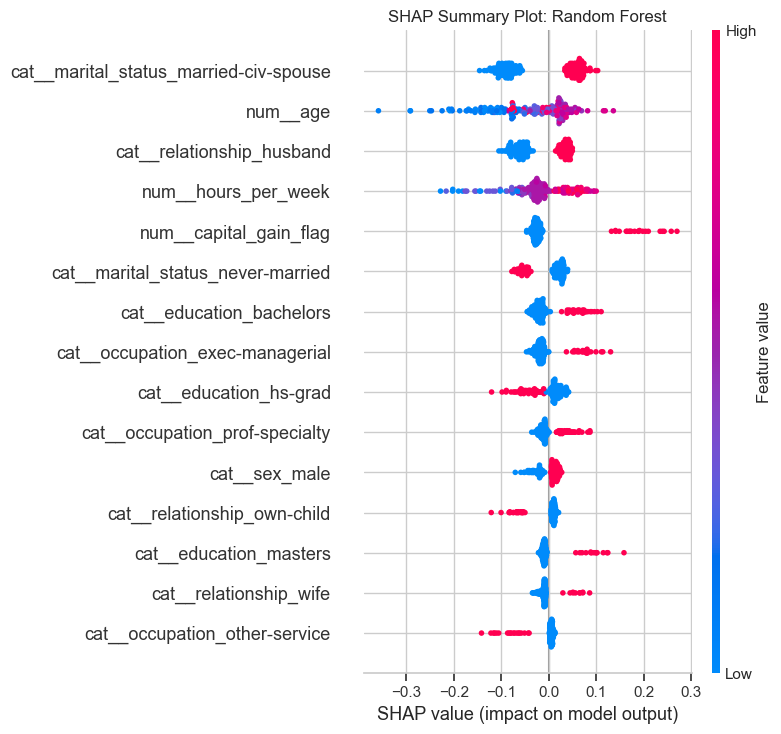

Saved: outputs/shap_summary_beeswarm.png


In [59]:
if SHAP_AVAILABLE:
    shap.summary_plot(
        shap_values,
        X_shap_transformed_df,
        max_display=15,
        show=False,
    )
    plt.title(f"SHAP Summary Plot: {best_model_name}")
    plt.tight_layout()
    plt.savefig("outputs/shap_summary_beeswarm.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved: outputs/shap_summary_beeswarm.png")


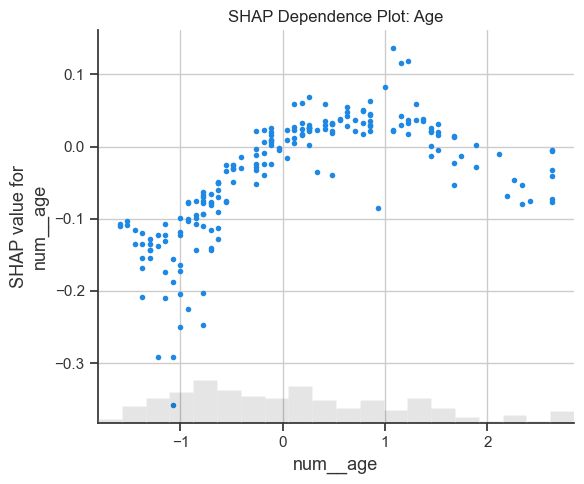

Saved: outputs/shap_dependence_age.png


In [60]:
if SHAP_AVAILABLE:

    age_feature = None

    for col in shap_feature_names:
        if col.endswith("age") or col == "num__age":
            age_feature = col
            break

    if age_feature is not None:

        shap.plots.scatter(
            shap.Explanation(
                values=shap_values,
                data=X_shap_transformed_df.values,
                feature_names=list(shap_feature_names),
            )[:, age_feature],
            show=False,
        )

        plt.title("SHAP Dependence Plot: Age")
        plt.tight_layout()

        plt.savefig(
            "outputs/shap_dependence_age.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

        print("Saved: outputs/shap_dependence_age.png")

> #### SHAP Dependence Plot
>
> A dependence plot shows how the SHAP value of a feature changes as the feature value changes.
>
> Unlike a global importance ranking, it reveals whether larger or smaller values of a feature tend to increase or decrease the probability of earning more than `>50K`.

Local explanation row index: 12719
Predicted probability of >50K: 0.9915
Actual class: >50K


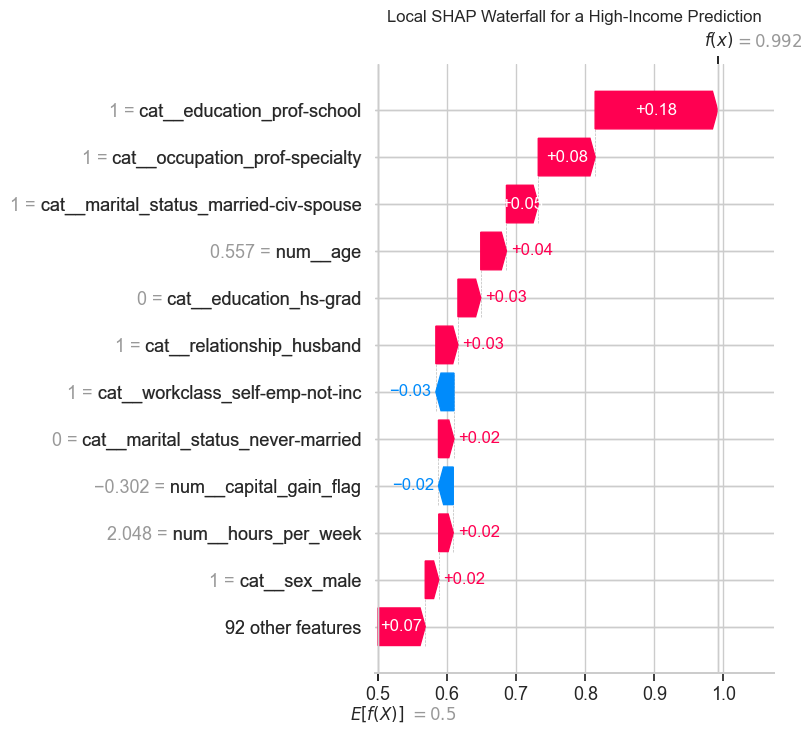

Saved: outputs/shap_local_waterfall.png


In [61]:
if SHAP_AVAILABLE:
    # Explain one high-income prediction with the highest predicted probability.
    shap_scores = best_final_model.predict_proba(X_shap_raw)[:, 1]
    local_position = int(np.argmax(shap_scores))
    local_index = X_shap_raw.index[local_position]

    local_explanation = shap.Explanation(
        values=shap_values[local_position],
        base_values=shap_base_value,
        data=X_shap_transformed_df.iloc[local_position].values,
        feature_names=list(shap_feature_names),
    )

    print("Local explanation row index:", local_index)
    print(f"Predicted probability of >50K: {shap_scores[local_position]:.4f}")
    print("Actual class:", ">50K" if y_test.loc[local_index] == 1 else "<=50K")

    shap.plots.waterfall(local_explanation, max_display=12, show=False)
    plt.title("Local SHAP Waterfall for a High-Income Prediction")
    plt.tight_layout()
    plt.savefig("outputs/shap_local_waterfall.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved: outputs/shap_local_waterfall.png")


#### Interpretation

The SHAP analysis provides both global and local explanations for the selected Random Forest model.

The global SHAP importance ranking is broadly consistent with the permutation importance results, indicating that **marital status**, **education**, **relationship**, **occupation**, and **age** are the most influential predictors of income. This consistency increases confidence that these variables genuinely drive model predictions rather than appearing important due to a specific explanation method.

The SHAP summary plot extends the feature-importance analysis by showing not only which variables are important, but also how they influence predictions. Individual SHAP values can either increase or decrease the probability of belonging to the `>50K` income class, depending on the feature values.

Finally, the waterfall plot demonstrates a local explanation for a single prediction. Starting from the baseline prediction, each feature contributes positively or negatively until the final predicted probability is reached. This illustrates how SHAP can provide transparent, instance-level explanations in addition to overall model interpretation.

## 14. PDP / ICE Check

While SHAP explains feature contributions, PDP and ICE help show how the predicted probability of earning `>50K` changes when a numerical feature varies.

In this project, PDP/ICE is applied to `age` and `hours_per_week` because they are continuous and easy to interpret. The PDP line shows the average effect learned by the model, while ICE lines show individual-level variation.

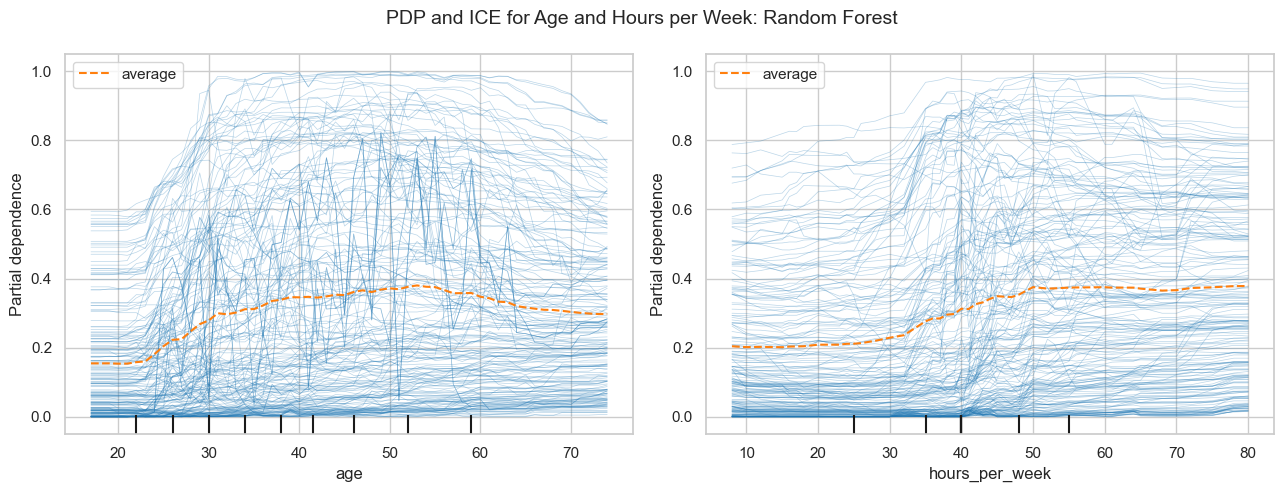

Saved: outputs/pdp_ice_age_hours.png


In [99]:
from sklearn.inspection import PartialDependenceDisplay

# Use a sample to keep PDP/ICE computation efficient
X_pdp = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=RANDOM_STATE
)

pdp_features = ["age", "hours_per_week"]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

PartialDependenceDisplay.from_estimator(
    best_final_model,
    X_pdp,
    features=pdp_features,
    kind="both",          # PDP + ICE
    subsample=200,
    random_state=RANDOM_STATE,
    ax=ax,
)

plt.suptitle(
    f"PDP and ICE for Age and Hours per Week: {best_model_name}",
    fontsize=14
)
plt.tight_layout()
plt.savefig("outputs/pdp_ice_age_hours.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: outputs/pdp_ice_age_hours.png")

#### Interpretation

The PDP/ICE plots show that both age and weekly working hours influence the Random Forest model's predicted probability of earning more than $50K. 

For age, the average predicted probability increases from young adulthood to middle age and then slightly declines after around 60. For hours per week, the probability increases notably between part-time and full-time/longer working hours, then becomes relatively stable after around 50 hours. The wide spread of ICE curves indicates that these effects vary across individuals, suggesting interactions with other features such as education, occupation, and marital status. 

## 15. Stakeholder Visualisations

This section converts the modelling results into visuals that are easier for non-technical stakeholders to interpret. The goal is to communicate model performance, confidence, and practical threshold trade-offs without requiring stakeholders to understand cross-validation or SHAP internals.


In [62]:
stakeholder_scores = best_final_model.predict_proba(X_test)[:, 1]
stakeholder_predictions = (stakeholder_scores >= 0.5).astype(int)

stakeholder_results = X_test.copy()
stakeholder_results["actual_income"] = np.where(y_test.values == 1, ">50K", "<=50K")
stakeholder_results["predicted_income"] = np.where(stakeholder_predictions == 1, ">50K", "<=50K")
stakeholder_results["probability_gt_50k"] = stakeholder_scores

stakeholder_results[["actual_income", "predicted_income", "probability_gt_50k"]].head()


,actual_income,predicted_income,probability_gt_50k
20325,<=50K,<=50K,0.087053
23863,>50K,>50K,0.853710
1445,<=50K,>50K,0.570998
25855,<=50K,<=50K,0.025112
5872,<=50K,<=50K,0.449881


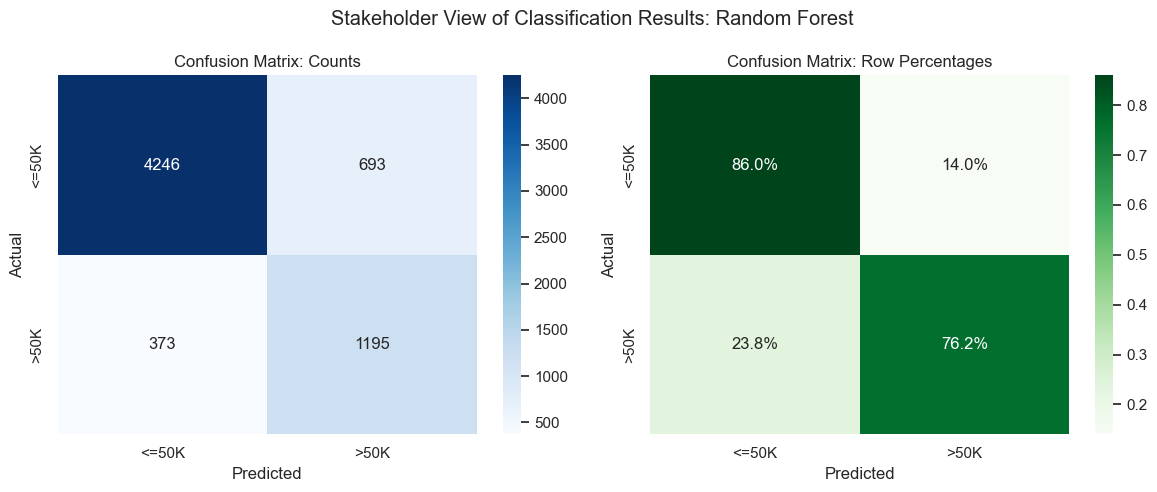

Saved: outputs/stakeholder_confusion_matrix.png


In [63]:
cm = confusion_matrix(y_test, stakeholder_predictions)
cm_percent = cm / cm.sum(axis=1, keepdims=True)
labels = ["<=50K", ">50K"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Confusion Matrix: Counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_percent, annot=True, fmt=".1%", cmap="Greens", xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Confusion Matrix: Row Percentages")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle(f"Stakeholder View of Classification Results: {best_model_name}")
plt.tight_layout()
plt.savefig("outputs/stakeholder_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: outputs/stakeholder_confusion_matrix.png")


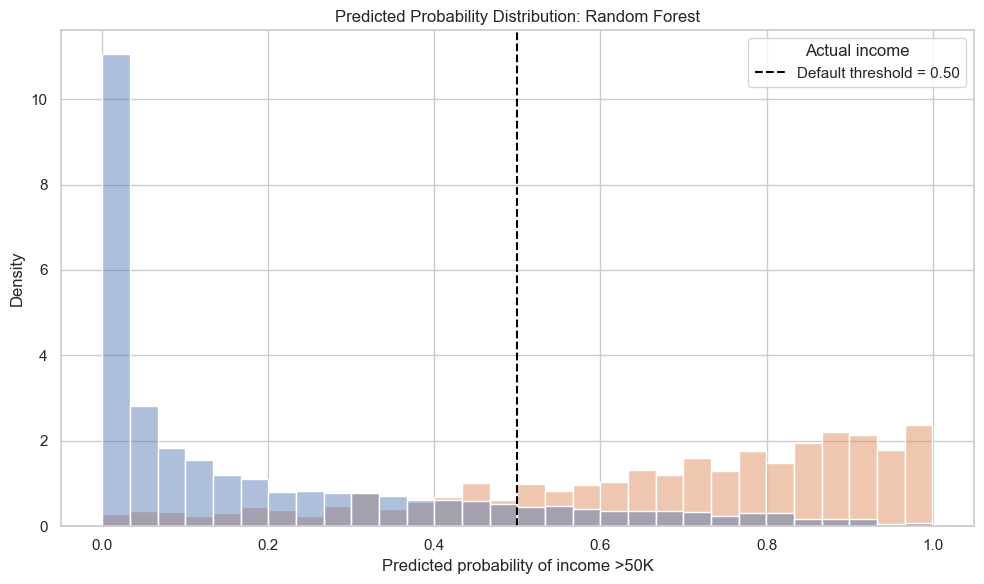

Saved: outputs/stakeholder_probability_distribution.png


In [64]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=stakeholder_results,
    x="probability_gt_50k",
    hue="actual_income",
    bins=30,
    stat="density",
    common_norm=False,
    alpha=0.45,
)
plt.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Default threshold = 0.50")
plt.title(f"Predicted Probability Distribution: {best_model_name}")
plt.xlabel("Predicted probability of income >50K")
plt.ylabel("Density")
plt.legend(title="Actual income")
plt.tight_layout()
plt.savefig("outputs/stakeholder_probability_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: outputs/stakeholder_probability_distribution.png")


,threshold,precision,recall,f1,predicted_positive_rate
0,0.10,0.3920,0.9675,0.5579,0.5947
1,0.15,0.4302,0.9554,0.5933,0.5351
2,0.20,0.4604,0.9343,0.6168,0.4890
3,0.25,0.4873,0.9165,0.6363,0.4532
4,0.30,0.5160,0.8973,0.6552,0.4191
5,0.35,0.5429,0.8642,0.6668,0.3836
6,0.40,0.5744,0.8393,0.6820,0.3521
7,0.45,0.6029,0.8055,0.6896,0.3220
8,0.50,0.6329,0.7621,0.6916,0.2901
9,0.55,0.6612,0.7168,0.6879,0.2613


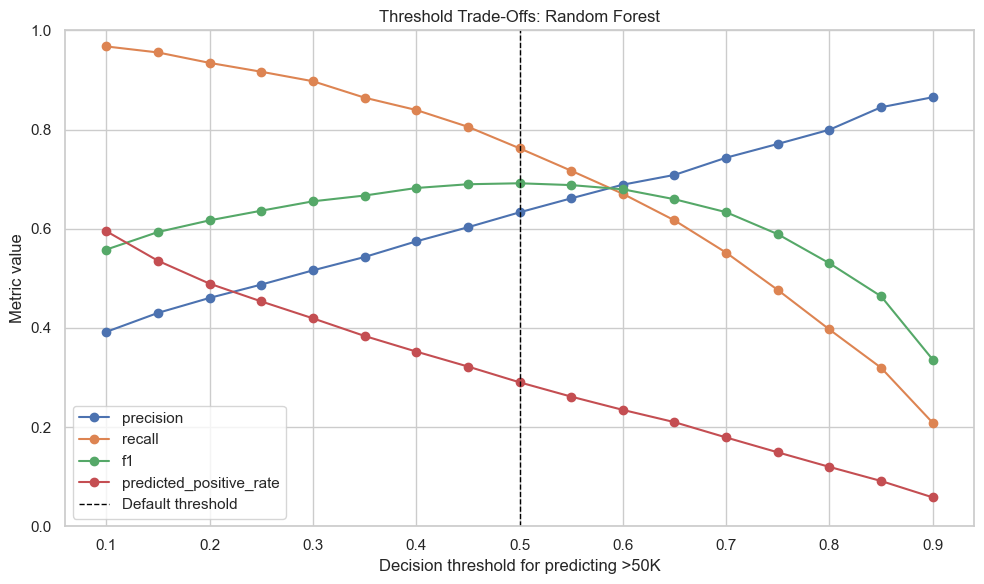

Saved: outputs/stakeholder_threshold_tradeoffs.png
Saved: outputs/stakeholder_threshold_tradeoffs.csv


In [65]:
threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.05):
    threshold_pred = (stakeholder_scores >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, threshold_pred, zero_division=0),
        "recall": recall_score(y_test, threshold_pred, zero_division=0),
        "f1": f1_score(y_test, threshold_pred, zero_division=0),
        "predicted_positive_rate": threshold_pred.mean(),
    })

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.round(4))

plt.figure(figsize=(10, 6))
for metric in ["precision", "recall", "f1", "predicted_positive_rate"]:
    plt.plot(threshold_table["threshold"], threshold_table[metric], marker="o", label=metric)

plt.axvline(0.5, color="black", linestyle="--", linewidth=1, label="Default threshold")
plt.title(f"Threshold Trade-Offs: {best_model_name}")
plt.xlabel("Decision threshold for predicting >50K")
plt.ylabel("Metric value")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig("outputs/stakeholder_threshold_tradeoffs.png", dpi=300, bbox_inches="tight")
plt.show()

threshold_table.to_csv("outputs/stakeholder_threshold_tradeoffs.csv", index=False)
print("Saved: outputs/stakeholder_threshold_tradeoffs.png")
print("Saved: outputs/stakeholder_threshold_tradeoffs.csv")


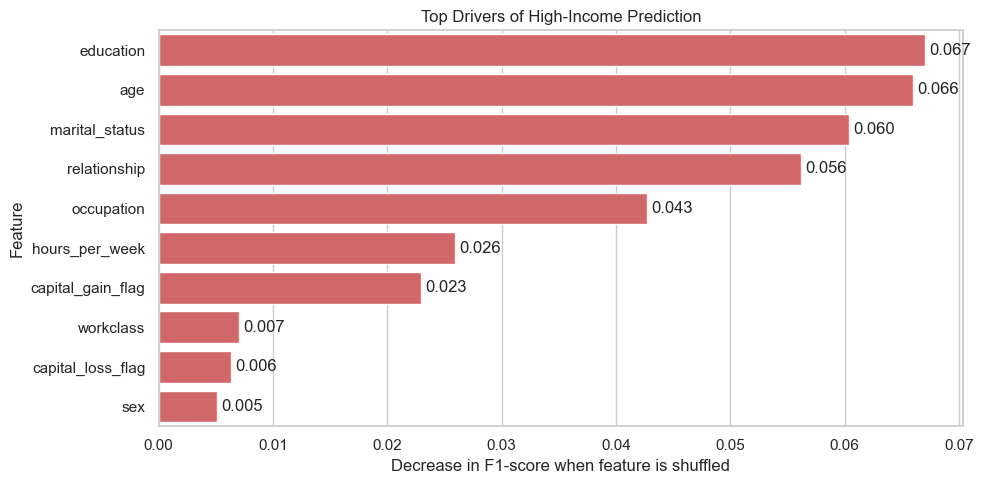

Saved: outputs/stakeholder_top_drivers.png


In [66]:
if "permutation_importance_df" in globals():
    stakeholder_importance = permutation_importance_df.head(10).copy()
    stakeholder_importance["importance_label"] = stakeholder_importance["importance_mean"].round(3)

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        data=stakeholder_importance,
        x="importance_mean",
        y="feature",
        color="#E15759",
    )
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3)
    plt.title("Top Drivers of High-Income Prediction")
    plt.xlabel("Decrease in F1-score when feature is shuffled")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("outputs/stakeholder_top_drivers.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved: outputs/stakeholder_top_drivers.png")


In [68]:
stakeholder_summary = pd.DataFrame([
    {
        "selected_model": best_model_name,
        "test_accuracy": accuracy_score(y_test, stakeholder_predictions),
        "test_precision": precision_score(y_test, stakeholder_predictions, zero_division=0),
        "test_recall": recall_score(y_test, stakeholder_predictions, zero_division=0),
        "test_f1": f1_score(y_test, stakeholder_predictions, zero_division=0),
        "test_roc_auc": roc_auc_score(y_test, stakeholder_scores),
        "test_pr_auc": average_precision_score(y_test, stakeholder_scores),
        "positive_class_rate": y_test.mean(),
        "predicted_positive_rate_at_0_5": stakeholder_predictions.mean(),
    }
])

display(stakeholder_summary.round(4))
stakeholder_summary.to_csv("outputs/stakeholder_model_summary.csv", index=False)
print("Saved: outputs/stakeholder_model_summary.csv")


,selected_model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,positive_class_rate,predicted_positive_rate_at_0_5
0,Random Forest,0.8362,0.6329,0.7621,0.6916,0.8982,0.7359,0.241,0.2901


Saved: outputs/stakeholder_model_summary.csv


#### Interpretation

The stakeholder visualisations translate the technical model results into operational insights. The confusion matrix shows that the model correctly identifies most high-income individuals while still missing a minority of positive cases. Overall, the model achieves an accuracy of 0.836, with a Recall of 0.762 for the >50K class, indicating that approximately three-quarters of high-income individuals are successfully detected.

The predicted probability distribution indicates that the model separates the two income groups reasonably well, although some overlap remains around the default decision threshold of 0.50. This suggests that while the model has strong discriminative ability (ROC-AUC = 0.898), some borderline cases are inevitably more difficult to classify.

The threshold trade-off analysis demonstrates the practical impact of changing the decision threshold. Lowering the threshold (e.g., to 0.30) increases Recall to approximately 0.90 but reduces Precision to about 0.52, resulting in more false positives. Raising the threshold (e.g., to 0.70) improves Precision to approximately 0.74, but Recall falls to around 0.55, meaning more high-income individuals are missed. Among the evaluated thresholds, the default threshold of 0.50 achieves the highest F1-score (0.692), providing the best balance between Precision and Recall. Therefore, it is retained as the recommended operating threshold for this project.

## 16. Failure Modes & Limitations

A single overall score can hide where and how a model fails. Following the failure-mode analysis idea, this section examines the selected final model, Random Forest, beyond aggregate performance metrics. The analysis focuses on classification error types, subgroup-level performance, potential fairness concerns, class imbalance, generalizability, and overfitting risk.

### 16.1 Confusion Matrix and Error Types

The confusion matrix generated in Section 14 is reused here to examine the final Random Forest model's main error types. Since the same final model and default decision threshold of 0.5 are used, the stakeholder confusion matrix already provides both count-based and percentage-based views of correct and incorrect predictions.

In this income prediction task, the four confusion matrix outcomes have the following meanings:

- True Positive (TP): actual income is `>50K` and the model predicts `>50K`.
- True Negative (TN): actual income is `<=50K` and the model predicts `<=50K`.
- False Positive (FP): actual income is `<=50K` but the model predicts `>50K`.
- False Negative (FN): actual income is `>50K` but the model predicts `<=50K`.

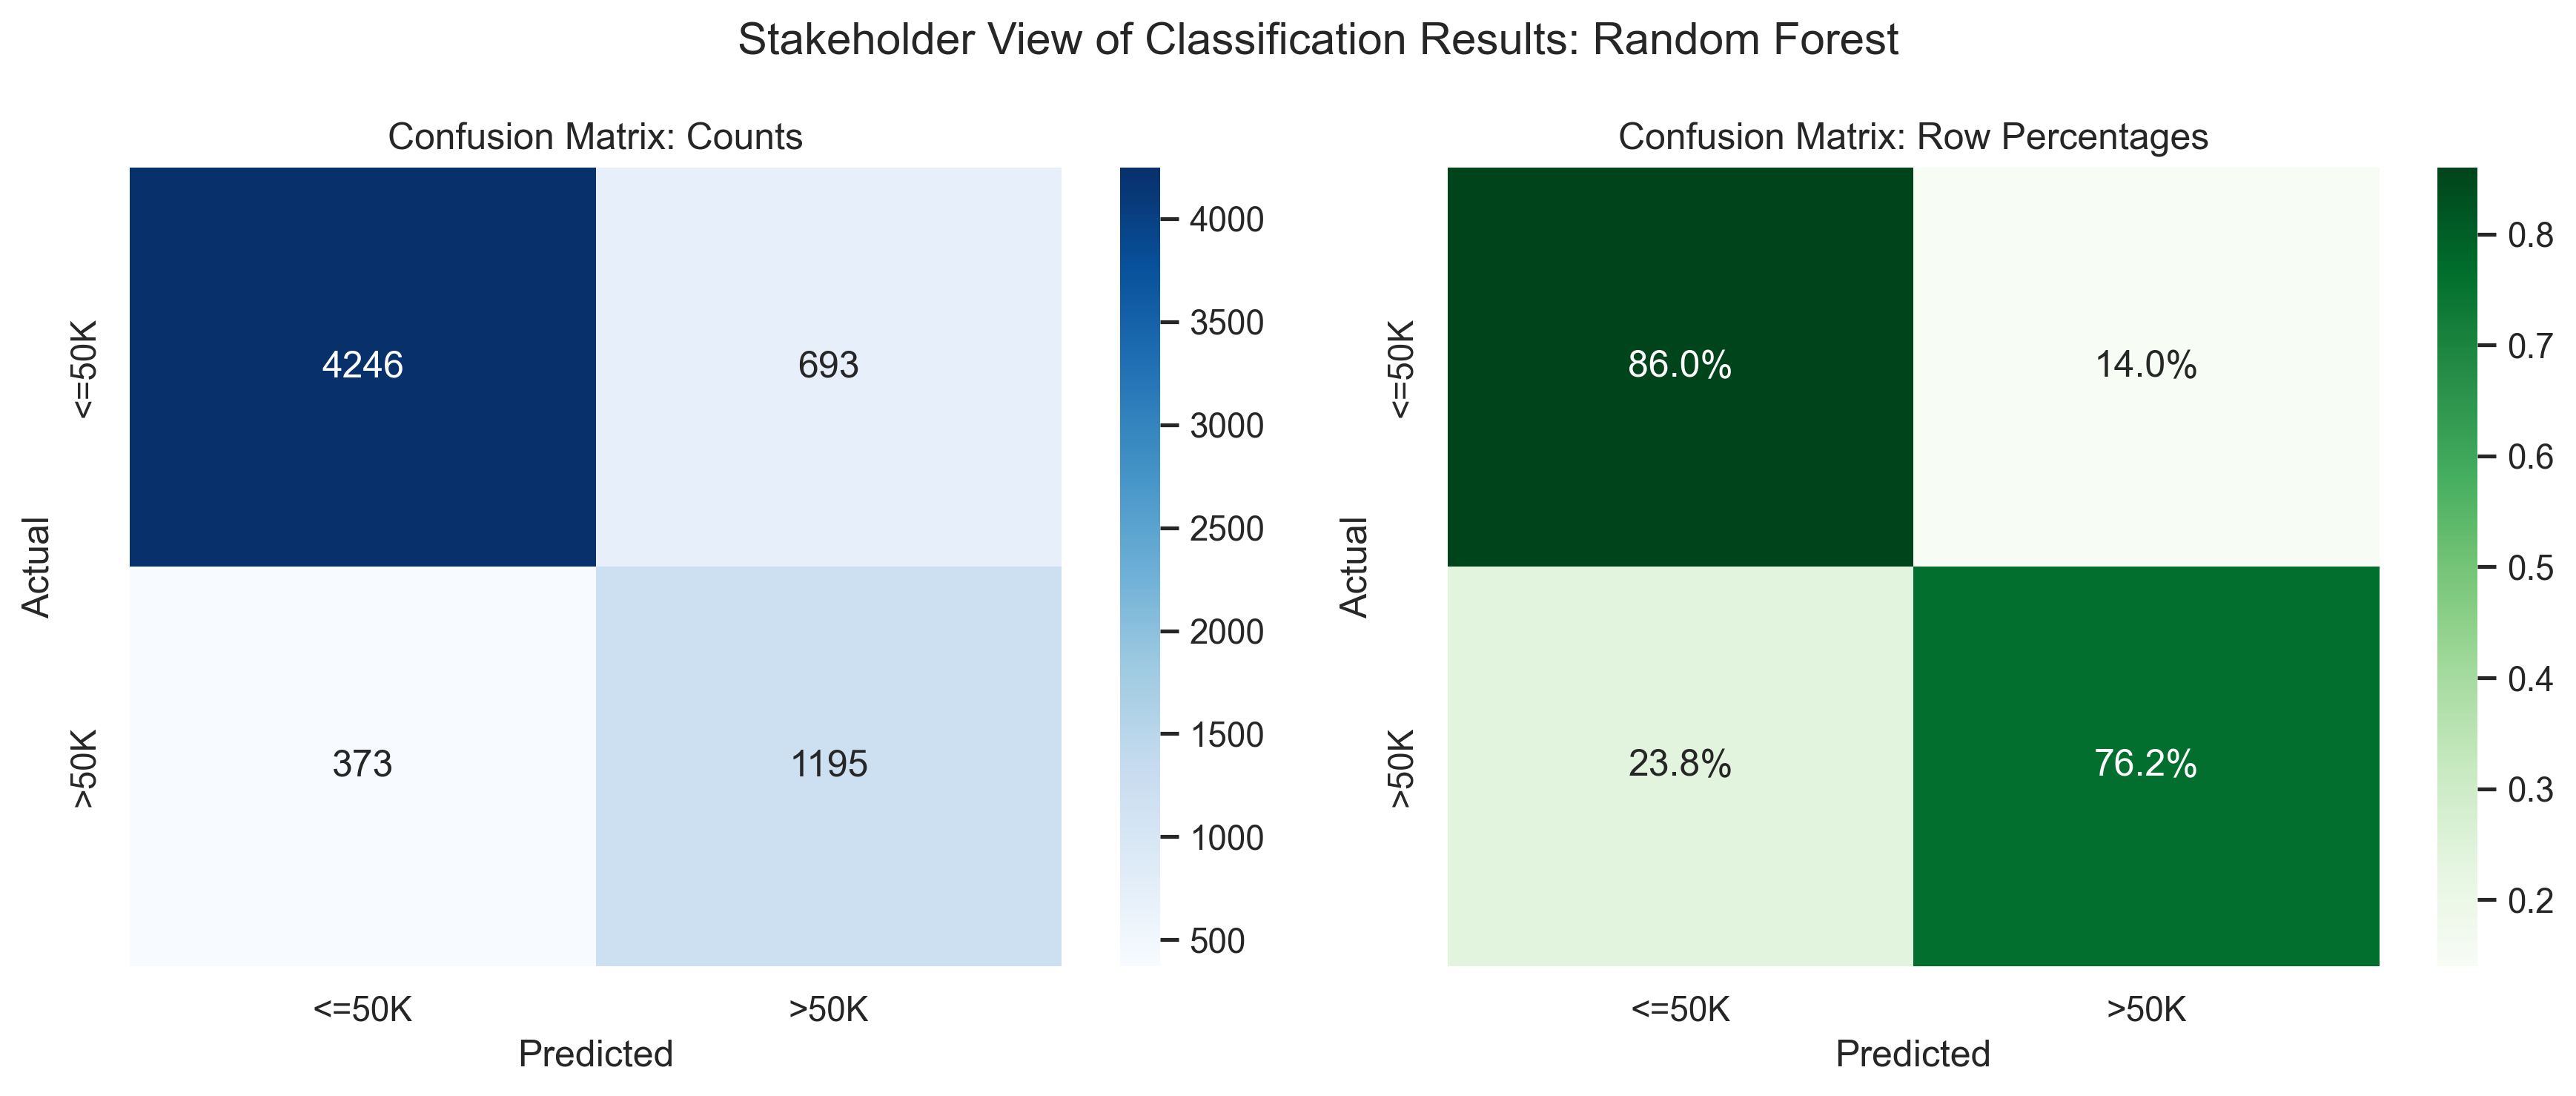

In [71]:
from IPython.display import Image, display

display(Image(filename="outputs/stakeholder_confusion_matrix.png"))

#### Interpretation

False negatives are especially important because they represent individuals who actually earn more than $50K but are missed by the model. In a workforce analytics context, this means the model may fail to identify some high-income or high-potential profiles.

False positives represent individuals whose income level is overestimated by the model. This may lead to overly optimistic income classification for some lower-income individuals.

### 16.2 Error Slice Analysis

Aggregate model performance may hide poor performance for specific demographic or employment groups. To examine this, the model is evaluated separately across important slices, including sex, education, race, and occupation. For each group, Accuracy, Recall, and F1-score are calculated.

In [72]:
slice_data = X_test.copy()
slice_data["actual"] = y_test.values
slice_data["predicted"] = failure_pred
slice_data["score"] = failure_scores

def slice_metrics(data, group_col, min_group_size=30):
    rows = []

    for group_value, group_df in data.groupby(group_col):
        if len(group_df) < min_group_size:
            continue

        y_true_group = group_df["actual"]
        y_pred_group = group_df["predicted"]

        rows.append({
            "slice_variable": group_col,
            "group": group_value,
            "n": len(group_df),
            "positive_rate": y_true_group.mean(),
            "predicted_positive_rate": y_pred_group.mean(),
            "accuracy": accuracy_score(y_true_group, y_pred_group),
            "recall": recall_score(y_true_group, y_pred_group, zero_division=0),
            "f1": f1_score(y_true_group, y_pred_group, zero_division=0),
        })

    return pd.DataFrame(rows)

slice_columns = ["sex", "education", "race", "occupation"]

slice_results = pd.concat(
    [slice_metrics(slice_data, col) for col in slice_columns],
    ignore_index=True
)

slice_results = slice_results.sort_values(
    ["slice_variable", "f1"],
    ascending=[True, True]
).reset_index(drop=True)

display(slice_results.round(4))

slice_results.to_csv("outputs/error_slice_analysis.csv", index=False)
print("Saved: outputs/error_slice_analysis.csv")

,slice_variable,group,n,positive_rate,predicted_positive_rate,accuracy,recall,f1
0,education,5th-6th,58,0.0000,0.0000,1.0000,0.0000,0.0000
1,education,7th-8th,131,0.0534,0.0229,0.9237,0.0000,0.0000
2,education,9th,114,0.0439,0.0000,0.9561,0.0000,0.0000
3,education,11th,241,0.0498,0.0166,0.9502,0.1667,0.2500
4,education,12th,74,0.0541,0.0811,0.9189,0.5000,0.4000
5,education,10th,182,0.0714,0.0879,0.9066,0.4615,0.4138
6,education,hs-grad,2093,0.1586,0.1811,0.8399,0.5663,0.5288
7,education,some-college,1465,0.1898,0.2369,0.8218,0.6547,0.5824
8,education,assoc-voc,265,0.3094,0.3585,0.7698,0.7073,0.6554
9,education,assoc-acdm,224,0.2500,0.3393,0.8125,0.8036,0.6818


Saved: outputs/error_slice_analysis.csv


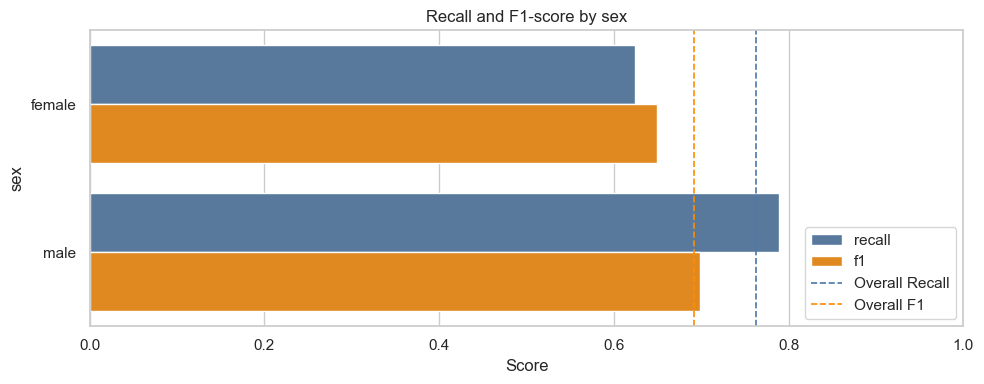

Saved: outputs/error_slice_sex_recall_f1.png


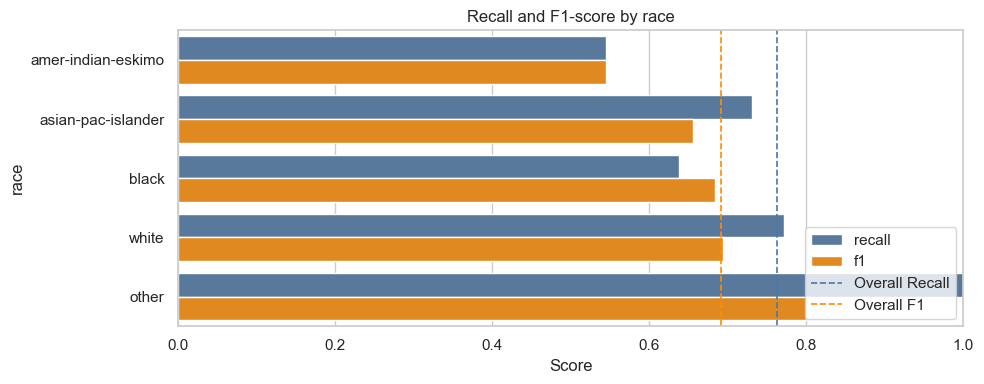

Saved: outputs/error_slice_race_recall_f1.png


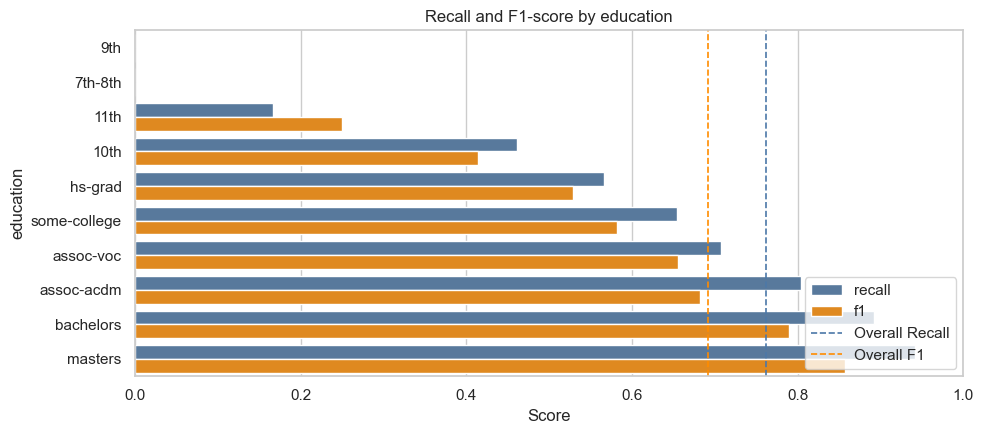

Saved: outputs/error_slice_education_recall_f1.png


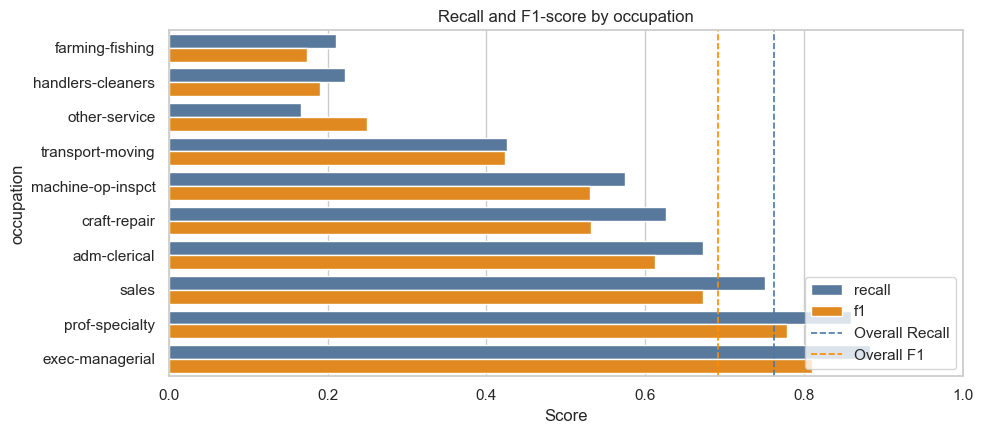

Saved: outputs/error_slice_occupation_recall_f1.png


In [92]:
# Visualise Recall and F1 by selected group variables

def plot_slice_recall_f1(slice_results, slice_variable, top_n=None):
    plot_df = slice_results[slice_results["slice_variable"] == slice_variable].copy()

    if top_n is not None:
        plot_df = plot_df.sort_values("n", ascending=False).head(top_n)

    plot_df = plot_df.sort_values("f1", ascending=True)

    plot_long = plot_df.melt(
        id_vars=["group", "n"],
        value_vars=["recall", "f1"],
        var_name="metric",
        value_name="score"
    )

    plt.figure(figsize=(10, max(4, 0.45 * len(plot_df))))
    sns.barplot(
        data=plot_long,
        x="score",
        y="group",
        hue="metric",
        palette=["#4C78A8", "#FF8C00"]
    )

    plt.axvline(
        stakeholder_summary["test_recall"].iloc[0],
        color="#4C78A8",
        linestyle="--",
        linewidth=1.2,
        label="Overall Recall"
    )

    plt.axvline(
        stakeholder_summary["test_f1"].iloc[0],
        color="#FF8C00",
        linestyle="--",
        linewidth=1.2,
        label="Overall F1"
    )

    plt.title(f"Recall and F1-score by {slice_variable}")
    plt.xlabel("Score")
    plt.ylabel(slice_variable)
    plt.xlim(0, 1)
    plt.legend(loc="lower right")
    plt.tight_layout()

    file_name = f"outputs/error_slice_{slice_variable}_recall_f1.png"
    plt.savefig(file_name, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {file_name}")

plot_slice_recall_f1(slice_results, "sex")
plot_slice_recall_f1(slice_results, "race")
plot_slice_recall_f1(slice_results, "education", top_n=10)
plot_slice_recall_f1(slice_results, "occupation", top_n=10)

#### Interpretation

The error slice analysis shows that model performance is not uniform across all demographic and employment groups. The grouped Recall and F1 visualisations indicate that the model performs better for groups with clearer income patterns and sufficient high-income examples, but performs worse for some lower-income or smaller subgroups:

For education, the model performs strongly for higher education groups such as `bachelors`, `masters`, where Recall and F1-scores are relatively high. However, performance is much weaker for lower education groups such as `7th-8th`, `9th`.

For occupation, the model performs better for groups such as `exec-managerial`, `prof-specialty`, `tech-support`, and `protective-serv`, while it performs worse for occupations such as `farming-fishing`, `handlers-cleaners`, and `other-service`. These lower-performing groups also have lower high-income rates, which makes accurate high-income prediction more difficult.

For sex, the model has a higher F1-score for males than females. Male individuals have a higher positive rate in the dataset, while female individuals have fewer `>50K` examples. 

For race, the results show some variation across groups. However, smaller groups such as `other` and `amer-indian-eskimo` should be interpreted carefully because their sample sizes are limited. Overall, the slice analysis shows that a strong overall F1-score can still hide weaker performance for specific subgroups.

### 16.3 Overfitting Check

To check for possible overfitting, the cross-validation F1-score from hyperparameter tuning is compared with the test-set F1-score. If the cross-validation score is much higher than the test score, this may indicate that the model overfits the training data or validation folds. If the two scores are close, the model is more likely to generalize reliably.

In [75]:
cv_test_rows = []

search_objects = {
    "Logistic Regression": "logistic_search",
    "Decision Tree": "tree_search",
    "Random Forest": "rf_search",
    xgb_model_name if "xgb_model_name" in globals() else "XGBoost": "xgb_search",
}

for model_name, search_name in search_objects.items():
    if search_name in globals():
        search_obj = globals()[search_name]

        test_row = comparison_table[comparison_table["model"] == model_name]

        if len(test_row) == 0:
            # fallback for display-name mismatch
            test_row = comparison_table[
                comparison_table["model"].astype(str).str.contains(model_name, case=False, regex=False)
            ]

        if len(test_row) > 0:
            best_idx = search_obj.best_index_
            mean_train_f1 = search_obj.cv_results_.get("mean_train_score", [np.nan])[best_idx]

            cv_test_rows.append({
                "model": model_name,
                "best_cv_f1": search_obj.best_score_,
                "mean_train_f1_at_best_params": mean_train_f1,
                "test_f1": float(test_row.iloc[0]["f1"]),
                "cv_test_gap": search_obj.best_score_ - float(test_row.iloc[0]["f1"]),
                "train_cv_gap": mean_train_f1 - search_obj.best_score_,
            })

overfitting_check = pd.DataFrame(cv_test_rows)
display(overfitting_check.round(4))

overfitting_check.to_csv("outputs/overfitting_check.csv", index=False)
print("Saved: outputs/overfitting_check.csv")

,model,best_cv_f1,mean_train_f1_at_best_params,test_f1,cv_test_gap,train_cv_gap
0,Logistic Regression,0.6696,0.6721,0.6754,-0.0058,0.0025
1,Decision Tree,0.6463,0.6887,0.6486,-0.0023,0.0424
2,Random Forest,0.6748,0.8266,0.6916,-0.0168,0.1518
3,XGBoost,0.6614,0.7192,0.6739,-0.0124,0.0577


Saved: outputs/overfitting_check.csv


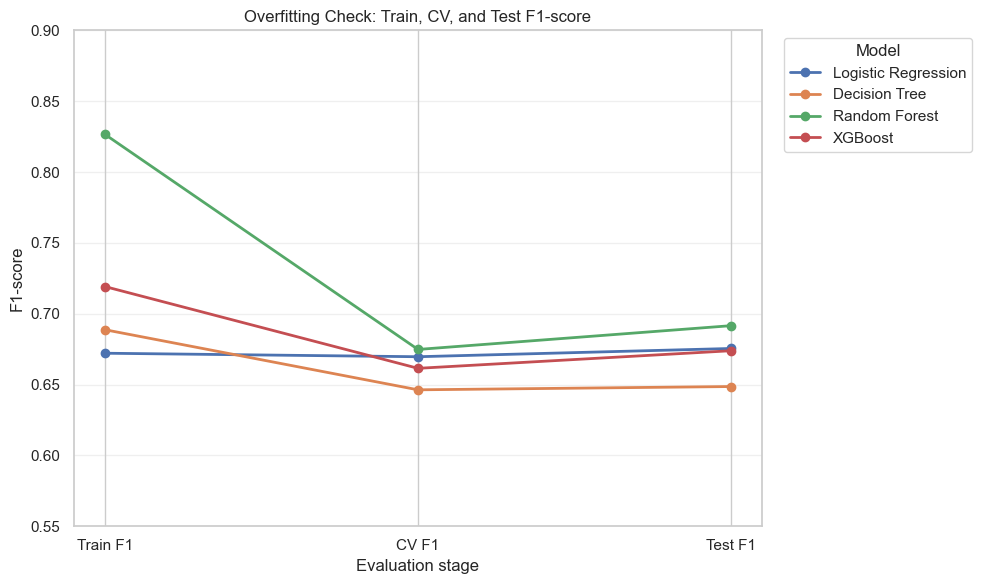

Saved: outputs/overfitting_train_cv_test_connected.png


In [96]:
# Visualisation: Train, CV, and Test F1 Connected Dot Plot

overfit_long = overfitting_check.melt(
    id_vars="model",
    value_vars=[
        "mean_train_f1_at_best_params",
        "best_cv_f1",
        "test_f1"
    ],
    var_name="score_type",
    value_name="f1_score"
)

score_label_map = {
    "mean_train_f1_at_best_params": "Train F1",
    "best_cv_f1": "CV F1",
    "test_f1": "Test F1"
}

overfit_long["score_type"] = overfit_long["score_type"].map(score_label_map)

score_order = ["Train F1", "CV F1", "Test F1"]

plt.figure(figsize=(10, 6))

for model in overfitting_check["model"]:
    model_df = overfit_long[overfit_long["model"] == model].copy()
    model_df["score_type"] = pd.Categorical(
        model_df["score_type"],
        categories=score_order,
        ordered=True
    )
    model_df = model_df.sort_values("score_type")

    plt.plot(
        model_df["score_type"],
        model_df["f1_score"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Overfitting Check: Train, CV, and Test F1-score")
plt.xlabel("Evaluation stage")
plt.ylabel("F1-score")
plt.ylim(0.55, 0.90)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/overfitting_train_cv_test_connected.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: outputs/overfitting_train_cv_test_connected.png")

#### Interpretation

The connected dot plot compares training F1, cross-validation F1, and test F1 for each model. A large drop from training F1 to CV/Test F1 suggests possible overfitting. Random Forest shows a noticeable train-CV gap, indicating high model capacity, but its test F1 remains close to or higher than its CV F1. This suggests that although the model fits the training data strongly, it still generalizes reasonably well on the independent test set.